# Saccade‑aligned LFP average pipeline

**Environment:** Use the `eye_repo` conda environment.

This pipeline loads the exported `all_saccade_collection`, infers the required (animal, block) set, instantiates only those BlockSync blocks, filters to **synchronized (binocular) saccades only**, and computes **averaged LFP traces** aligned to saccade onset (t = 0), with **one average trace per animal** (no mixing across animals).

**Prerequisites:**
- Run `saccade_collection_pipeline.ipynb` and export `all_saccade_collection` to the configured `export_dir`.
- Electrophysiology (OE) data available for each block (`oe_rec` on BlockSync).

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from eye_tracking_system_tools.preprocessing import BlockSync
from eye_tracking_system_tools.preprocessing import utility_functions as uf

## Config

- `experiment_path`: parent of animal folders (same as saccade pipeline).
- `collection_path`: path to exported `all_saccade_collection.csv` (or use `export_dir` / `export_filename` from saccade pipeline).
- `lfp_channels`: list of OE channel numbers for LFP (e.g. `[1]`).
- `window_ms`: total window around saccade onset (ms). We use **± half_window**, so 100 ms → -50 to +50 ms.

In [2]:
experiment_path = Path(r"D:\sample_data_for_eye_repo")
export_dir = experiment_path / "analysis" / "saccade_collections"
export_filename = "all_saccade_collection.csv"
collection_path = export_dir / export_filename

lfp_channels = [1]   # OE channel numbers for LFP
window_ms = 200.0    # total window around onset (ms); we use ± window_ms/2
half_window_ms = window_ms / 2

## Load `all_saccade_collection` and infer required (animal, block) set

Load the exported collection, then derive unique `(animal, block)` pairs to instantiate only those BlockSync blocks.

In [3]:
all_saccade_collection = pd.read_csv(collection_path)
required = ["animal", "block", "Main", "Sub", "saccade_on_ms"]
missing = [c for c in required if c not in all_saccade_collection.columns]
if missing:
    raise ValueError(f"all_saccade_collection missing columns: {missing}")
print(f"Loaded {len(all_saccade_collection):,} rows from {collection_path.name}")

ab = all_saccade_collection[["animal", "block"]].drop_duplicates()
animals = ab["animal"].dropna().unique().astype(str).tolist()
block_lists = [
    [int(b) for b in ab.loc[ab["animal"] == a, "block"].dropna().unique().astype(str).tolist()]
    for a in animals
]
print(f"Inferred animals: {animals}; block_lists: {block_lists}")

Loaded 7,754 rows from all_saccade_collection.csv
Inferred animals: ['PV_126', 'PV_106', 'PV_208']; block_lists: [[6], [15], [19]]


## Build `block_collection` and `block_dict` for inferred (animal, block) only

Reuse the same helpers as the saccade pipeline. We need BlockSync instances with `oe_rec` for LFP extraction, and eye tracking data (`left_eye_data`/`right_eye_data` or `le_df`/`re_df`) for velocity extraction.

In [4]:
def create_block_collections(animals, block_lists, experiment_path, bad_blocks=None):
    """Build block_collection and block_dict from animals and block lists."""
    if bad_blocks is None:
        bad_blocks = []
    block_collection = []
    block_dict = {}
    for animal, blocks in zip(animals, block_lists):
        current = uf.block_generator(
            block_numbers=blocks,
            experiment_path=experiment_path,
            animal=animal,
            bad_blocks=bad_blocks,

        )
        block_collection.extend(current)
        for b in current:
            block_dict[f"{animal}_block_{b.block_num}"] = b
    return block_collection, block_dict

block_collection, block_dict = create_block_collections(
    animals=animals,
    block_lists=block_lists,
    experiment_path=experiment_path,
    bad_blocks=[],

)
print(f"Blocks: {list(block_dict.keys())}")

instantiated block number 006 at Path: D:\sample_data_for_eye_repo\PV_126\2024_07_18\block_006, new OE version
Found the sample rate for block 006 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_126\2024_07_18\block_006\oe_files\PV126_Trial15_hunter7_2024-07-18_12-25-35\Record Node 102...
xml data matches file data.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode)
retrieving zertoh sample number for block 006
got it!
instantiated block number 015 at Path: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015, new OE version
Found the sample rate for block 015 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015\oe_files\PV106_IMU_trial4_prey_2025-09-04_13-24-17\

## Filter saccades into sub-categories (with / without head movements)

Define sub-categories:
1. **Synchronized** – both eyes move at same time (one row per pair, no double-count).
2. **Monocular left** – only left eye crossed threshold (unpaired).
3. **Monocular right** – only right eye crossed threshold (unpaired).
4. **Conjugated** – synchronized saccades with similar direction (L–R angle difference ≤ 45°).
5. **Non-conjugated** – synchronized saccades with divergent direction (L–R angle difference > 45°).

For each category we keep two versions: **with head movements** (include all) and **no head movements** (exclude rows where `head_movement` is True). The `head_movement` column is set by the saccade collection pipeline via `block.block_get_lizard_movement()`: True if any movement epoch (`t_mov_ms` in `block.liz_mov_df`) falls inside the saccade interval `[saccade_on_ms, saccade_off_ms]`, else False. If `head_movement` is missing from the collection (e.g. pipeline run before labeling or no `lizMov.mat`), both versions use all rows and a note is printed.

In [5]:
# Head-movement mask: exclude saccades during head movement for "no_head" version
if "head_movement" in all_saccade_collection.columns:
    mask_no_head = ~all_saccade_collection["head_movement"].fillna(False).astype(bool)
    mask_with_head = np.ones(len(all_saccade_collection), dtype=bool)  # include all
else:
    mask_no_head = np.ones(len(all_saccade_collection), dtype=bool)
    mask_with_head = np.ones(len(all_saccade_collection), dtype=bool)
    print("Note: 'head_movement' column not in collection; with_head and no_head use same rows.")

# 1) Synchronized (one row per pair: keep Sub == "L" only)
synced = all_saccade_collection.dropna(subset=["Main"]).copy()
synced_one_per_pair = synced.query('Sub == "L"').copy()
synced_with_head = synced_one_per_pair.copy()
synced_no_head = synced_one_per_pair.loc[synced_one_per_pair.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"1. Synced (one per pair): with_head={len(synced_with_head)}, no_head={len(synced_no_head)}")

# 2) Monocular left (Main is NaN, eye == L)
mono_left = all_saccade_collection[all_saccade_collection["Main"].isna() & (all_saccade_collection["eye"] == "L")].copy()
mono_left_with_head = mono_left.copy()
mono_left_no_head = mono_left.loc[mono_left.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"2. Monocular left: with_head={len(mono_left_with_head)}, no_head={len(mono_left_no_head)}")

# 3) Monocular right (Main is NaN, eye == R)
mono_right = all_saccade_collection[all_saccade_collection["Main"].isna() & (all_saccade_collection["eye"] == "R")].copy()
mono_right_with_head = mono_right.copy()
mono_right_no_head = mono_right.loc[mono_right.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"3. Monocular right: with_head={len(mono_right_with_head)}, no_head={len(mono_right_no_head)}")

# 4) Conjugated / 5) Non-conjugated: need L–R angle difference per synced pair (requires "angle" column)
CONJUGATED_DEG = 45  # within this many degrees = conjugated
synced_l_full = synced.query('Sub == "L"').copy()
if "angle" in synced.columns:
    synced_l = synced.query('Sub == "L"')[["Main", "animal", "block", "angle", "saccade_on_ms"]].rename(columns={"angle": "angle_L"})
    synced_r = synced.query('Sub == "R"')[["Main", "angle"]].rename(columns={"angle": "angle_R"})
    pair_angles = synced_l.merge(synced_r, on="Main", how="inner")
    pair_angles["angle_diff"] = np.abs(pair_angles["angle_L"] - pair_angles["angle_R"])
    pair_angles["angle_diff"] = np.minimum(pair_angles["angle_diff"], 360 - pair_angles["angle_diff"])
    pair_angles["conjugated"] = pair_angles["angle_diff"] <= CONJUGATED_DEG
    pair_angles = pair_angles.set_index("Main")
    conj_main_ids = pair_angles.index[pair_angles["conjugated"]].values
    non_conj_main_ids = pair_angles.index[~pair_angles["conjugated"]].values
    conjugated_rows = synced_l_full[synced_l_full["Main"].isin(conj_main_ids)].copy()
    non_conjugated_rows = synced_l_full[synced_l_full["Main"].isin(non_conj_main_ids)].copy()
else:
    conjugated_rows = pd.DataFrame()
    non_conjugated_rows = pd.DataFrame()
    print("Note: 'angle' column missing; conjugated and non-conjugated collections are empty.")

conjugated_with_head = conjugated_rows.copy()
conjugated_no_head = conjugated_rows.loc[conjugated_rows.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
non_conjugated_with_head = non_conjugated_rows.copy()
non_conjugated_no_head = non_conjugated_rows.loc[non_conjugated_rows.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"4. Conjugated (angle diff ≤{CONJUGATED_DEG}°): with_head={len(conjugated_with_head)}, no_head={len(conjugated_no_head)}")
print(f"5. Non-conjugated (angle diff >{CONJUGATED_DEG}°): with_head={len(non_conjugated_with_head)}, no_head={len(non_conjugated_no_head)}")

# Collect all filtered DataFrames for iteration (name, df) for LFP and plotting
filtered_collections = [
    ("Synced (with head)", synced_with_head),
    ("Synced (no head)", synced_no_head),
    ("Monocular left (with head)", mono_left_with_head),
    ("Monocular left (no head)", mono_left_no_head),
    ("Monocular right (with head)", mono_right_with_head),
    ("Monocular right (no head)", mono_right_no_head),
    ("Conjugated (with head)", conjugated_with_head),
    ("Conjugated (no head)", conjugated_no_head),
    ("Non-conjugated (with head)", non_conjugated_with_head),
    ("Non-conjugated (no head)", non_conjugated_no_head),
]

1. Synced (one per pair): with_head=2483, no_head=1330
2. Monocular left: with_head=381, no_head=365
3. Monocular right: with_head=2407, no_head=1224
4. Conjugated (angle diff ≤45°): with_head=865, no_head=540
5. Non-conjugated (angle diff >45°): with_head=1618, no_head=790


## Extract LFP windows and average per animal (per filtered collection)

For each saccade in a filtered collection we fetch `window_ms` of LFP centered on saccade onset (onset → 0). We use **`saccade_on_ms`** from the collection (same timebase as block sync). `start = saccade_on_ms - half_window_ms`. We skip windows outside `[0, recordingDuration_ms)`. We **do not mix** traces across animals: one average trace per animal per filtered collection.

**LFP filtering:** Optionally filter out noisy LFP samples using `lfp_noise_filter_std` threshold (standard deviation threshold). Filtered samples are excluded from averages and saccade counts.

*Time alignment:* `saccade_on_ms` is assumed to match the OE recording timebase. If LFP traces look misaligned, verify sync pipeline output (e.g. `ms_axis` vs OE) and adjust.

In [6]:
all_saccade_collection.head()

,Main,Sub,saccade_start_ind,saccade_end_ind,saccade_start_timestamp,saccade_end_timestamp,saccade_on_ms,saccade_off_ms,length,magnitude_raw,...,initial_y,end_x,end_y,calib_dx,calib_dy,speed_profile,animal,block,eye,head_movement
0,0.0,L,2190,2196,729779.0,731777.0,36488.95,36588.85,6,24.592331,...,196.356210,270.883166,184.697354,-21.242692,-11.658856,[0.15319758 2.96997338 6.33994206 6.08489787 4...,PV_126,6,L,True
1,1.0,L,2506,2513,835007.0,837338.0,41750.35,41866.90,7,60.561245,...,190.614070,297.739474,245.321108,20.745093,54.707038,[ 0.07102976 3.4898665 13.70969686 17.607568...,PV_126,6,L,True
2,2.0,L,2865,2872,954554.0,956885.0,47727.70,47844.25,7,32.833104,...,241.096600,284.062062,212.778537,-13.188224,-28.318063,[ 0.08348481 2.62600956 7.90805306 10.249442...,PV_126,6,L,True
3,3.0,L,2959,2962,985856.0,986855.0,49292.80,49342.75,3,6.293793,...,210.068614,291.516649,213.018181,4.742750,2.949568,[0.45095165 2.03131395 2.31384361 1.49768378],PV_126,6,L,True
4,4.0,L,3668,3671,1221953.0,1222952.0,61097.65,61147.60,3,17.442817,...,210.294467,305.463792,219.896890,12.297983,9.602424,[1.81235473 7.85486561 6.34666541 1.42893093],PV_126,6,L,False


In [7]:
window_ms = 600
half_window_ms = window_ms / 2

# LFP noise filtering: set to None to disable, or a float threshold (std dev) to filter noisy samples
lfp_noise_filter_std = None  # e.g., 3.0 to filter samples with std > 3.0 across all windows

def _block_key(animal, block):
    b = str(block).strip()
    if len(b) < 3:
        b = b.zfill(3)
    return f"{animal}_block_{b}"

def _load_eye_data(block):
    """Load eye tracking data from BlockSync. Returns (left_eye_df, right_eye_df) or (None, None) if unavailable."""
    # Try left_eye_data/right_eye_data first (CSV files)
    if hasattr(block, "left_eye_data") and block.left_eye_data is not None:
        return block.left_eye_data, block.right_eye_data if hasattr(block, "right_eye_data") else None
    # Try le_df/re_df (legacy)
    if hasattr(block, "le_df") and block.le_df is not None:
        return block.le_df, block.re_df if hasattr(block, "re_df") else None
    # Try loading from CSV files
    try:
        ap = Path(block.analysis_path)
        lp = ap / "left_eye_data.csv"
        rp = ap / "right_eye_data.csv"
        if lp.exists() and rp.exists():
            left_df = pd.read_csv(lp, index_col=0, engine="python")
            right_df = pd.read_csv(rp, index_col=0, engine="python")
            return left_df, right_df
    except Exception:
        pass
    return None, None

def extract_mean_lfp_per_animal(collection_df, block_dict, lfp_channels, window_ms, half_window_ms, animals, noise_filter_std=None, desc_prefix="LFP"):
    """
    Extract LFP windows for each saccade in collection_df and average per animal.
    
    OPTIMIZATION: Uses BATCH extraction for performance. Instead of calling get_data() once per saccade,
    this function groups saccades by block and calls get_data() once per block with all start times.
    This reduces I/O operations dramatically (e.g., 1000 saccades → ~10-20 block calls instead of 1000 calls).
    
    Returns dict animal -> (t_rel_ms, mean_lfp, n_valid_samples, valid_rows_df).
    
    Args:
        noise_filter_std: If not None, filter out windows where std dev across time exceeds this threshold.
        desc_prefix: Prefix for progress bar description
    
    Returns:
        dict: animal -> (t_rel_ms, mean_lfp, n_valid_samples, valid_rows_df)
              where valid_rows_df contains only the rows that passed filtering
    """
    mean_lfp_per_animal = {}
    for animal in animals:
        rows = collection_df[collection_df["animal"] == animal].copy()
        if rows.empty:
            continue
        
        # Group saccades by block for batch extraction
        rows["block_key"] = rows.apply(lambda r: _block_key(r["animal"], r["block"]), axis=1)
        
        # Collect all valid saccades with their metadata
        saccade_info = []  # List of (row_idx, block_key, start_ms, row_data)
        dur_ms_cache = {}  # Cache recording durations
        
        for idx, r in rows.iterrows():
            block_key = r["block_key"]
            block = block_dict.get(block_key)
            if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
                continue
            
            # Cache duration check
            if block_key not in dur_ms_cache:
                dur_ms = getattr(block.oe_rec, "recordingDuration_ms", None)
                if dur_ms is not None:
                    dur_ms = float(dur_ms) if not hasattr(dur_ms, "item") else float(dur_ms.item())
                dur_ms_cache[block_key] = dur_ms
            
            onset_ms = float(r["saccade_on_ms"])
            start_ms = onset_ms - half_window_ms
            dur_ms = dur_ms_cache[block_key]
            
            if dur_ms is not None and (start_ms < 0 or start_ms + window_ms > dur_ms):
                continue
            
            saccade_info.append((idx, block_key, start_ms, r))
        
        if not saccade_info:
            continue
        
        # Group by block for batch extraction
        from collections import defaultdict
        block_groups = defaultdict(list)
        for idx, block_key, start_ms, r in saccade_info:
            block_groups[block_key].append((idx, start_ms, r))
        
        # Extract LFP windows using batch calls
        windows = []
        valid_rows = []
        total_blocks = len(block_groups)
        pbar = tqdm(block_groups.items(), total=total_blocks, desc=f"{desc_prefix} {animal}", leave=False)
        
        for block_key, saccade_list in pbar:
            block = block_dict.get(block_key)
            if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
                continue
            
            # Skip if no valid saccades for this block
            if not saccade_list:
                continue
            
            # Collect all start times for this block
            start_times_ms = [start_ms for _, start_ms, _ in saccade_list]
            # get_data expects shape [1, n_windows] - use atleast_2d to ensure correct shape
            start_arr = np.atleast_2d(np.array(start_times_ms, dtype=float))  # Shape: [1, n_windows]
            
            try:
                # Batch extraction: get all windows for this block in one call
                data, ts = block.oe_rec.get_data(
                    lfp_channels,
                    start_arr,
                    window_ms,
                    convert_microvolts=True,
                    return_timestamps=True,
                    repress_output=True,
                )
            except Exception as e:
                # If batch fails, skip this block
                pbar.set_postfix({"valid": len(valid_rows), "blocks": f"{len([k for k in block_groups.keys() if k != block_key])}/{total_blocks}"})
                continue
            
            if data is None or data.size == 0:
                continue
            
            # Extract individual windows from batch result
            # data shape: [n_channels, n_windows, n_samples]
            # For single channel: data[0, window_idx, :] gives the window
            n_windows_batch = data.shape[1]
            n_channels_batch = data.shape[0]
            
            for batch_idx, (orig_idx, start_ms, r) in enumerate(saccade_list):
                if batch_idx >= n_windows_batch:
                    continue
                
                # Extract window for this saccade
                if n_channels_batch == 1:
                    # Single channel: direct extraction
                    win = data[0, batch_idx, :]
                else:
                    # Multiple channels: take mean across channels (or could use first channel)
                    # Using mean to combine channels - adjust if different behavior needed
                    win = np.nanmean(data[:, batch_idx, :], axis=0)
                
                # Apply noise filter if specified
                if noise_filter_std is not None:
                    win_std = np.nanstd(win)
                    if win_std > noise_filter_std:
                        continue  # Skip this noisy window
                
                windows.append(win)
                valid_rows.append(r)
            
            pbar.set_postfix({"valid": len(valid_rows), "blocks": f"{len([k for k in block_groups.keys() if k != block_key])}/{total_blocks}"})
        
        pbar.close()
        
        if not windows:
            continue
        
        stack = np.stack(windows)
        mean_lfp = np.nanmean(stack, axis=0)
        n_samp = mean_lfp.size
        t_rel_ms = np.linspace(-half_window_ms, half_window_ms, n_samp, endpoint=True)
        n_valid = len(valid_rows)
        valid_rows_df = pd.DataFrame(valid_rows).reset_index(drop=True) if valid_rows else pd.DataFrame()
        mean_lfp_per_animal[animal] = (t_rel_ms, mean_lfp, n_valid, valid_rows_df)
    
    return mean_lfp_per_animal

def extract_mean_velocity_per_animal(collection_df, block_dict, window_ms, half_window_ms, animals, t_rel_ms_target=None, desc_prefix="Velocity"):
    """
    Extract velocity windows for each saccade and average per animal.
    Returns dict animal -> (t_rel_ms, mean_velocity).
    For synchronized saccades (Sub == "L"), uses left eye. For monocular, uses the appropriate eye.
    
    Args:
        collection_df: DataFrame with saccade rows (should be filtered to match LFP filtering).
        t_rel_ms_target: Optional time grid to interpolate velocity to (should match LFP time grid).
                         If None, creates a default grid.
        desc_prefix: Prefix for progress bar description
    """
    mean_velocity_per_animal = {}
    # Cache eye data per block to avoid reloading
    eye_data_cache = {}
    
    for animal in animals:
        rows = collection_df[collection_df["animal"] == animal]
        if rows.empty:
            continue
        windows = []
        total_rows = len(rows)
        pbar = tqdm(enumerate(rows.iterrows()), total=total_rows, desc=f"{desc_prefix} {animal}", leave=False)
        for idx, (_, r) in pbar:
            key = _block_key(r["animal"], r["block"])
            block = block_dict.get(key)
            if block is None:
                pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                continue
            
            # Determine which eye to use
            eye_side = None
            if "Sub" in r and pd.notna(r["Sub"]) and r["Sub"] == "L":
                eye_side = "left"
            elif "Sub" in r and pd.notna(r["Sub"]) and r["Sub"] == "R":
                eye_side = "right"
            elif "eye" in r:
                eye_side = "left" if r["eye"] == "L" else "right"
            else:
                # Default to left for synchronized saccades
                eye_side = "left"
            
            # Load eye data (use cache to avoid reloading for same block)
            cache_key = f"{key}_{eye_side}"
            if cache_key not in eye_data_cache:
                left_df, right_df = _load_eye_data(block)
                eye_df = left_df if eye_side == "left" else right_df
                if eye_df is None or "ms_axis" not in eye_df.columns:
                    eye_data_cache[cache_key] = None
                    pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                    continue
                
                # Calculate velocity if not already present
                if "velocity" not in eye_df.columns:
                    if "center_x" in eye_df.columns and "center_y" in eye_df.columns:
                        dx = eye_df["center_x"].diff().fillna(0)
                        dy = eye_df["center_y"].diff().fillna(0)
                        eye_df = eye_df.copy()
                        eye_df["velocity"] = np.sqrt(dx**2 + dy**2)
                    else:
                        eye_data_cache[cache_key] = None
                        pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                        continue
                eye_data_cache[cache_key] = eye_df
            else:
                eye_df = eye_data_cache[cache_key]
                if eye_df is None:
                    pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                    continue
            
            # Extract velocity window around saccade onset
            onset_ms = float(r["saccade_on_ms"])
            start_ms = onset_ms - half_window_ms
            end_ms = onset_ms + half_window_ms
            
            # Find indices in eye_df within the window
            mask = (eye_df["ms_axis"] >= start_ms) & (eye_df["ms_axis"] <= end_ms)
            window_data = eye_df.loc[mask].copy()
            
            if len(window_data) < 2:
                pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                continue
            
            # Interpolate to target time grid (or create default)
            t_rel_window = window_data["ms_axis"].values - onset_ms
            velocity_values = window_data["velocity"].fillna(0).values
            
            if t_rel_ms_target is not None:
                t_rel_uniform = t_rel_ms_target
            else:
                # Create default uniform time grid (~2ms resolution)
                n_samples = int(window_ms / 2)
                t_rel_uniform = np.linspace(-half_window_ms, half_window_ms, n_samples, endpoint=True)
            
            # Interpolate velocity to uniform grid
            if len(t_rel_window) > 1:
                velocity_interp = np.interp(t_rel_uniform, t_rel_window, velocity_values)
            else:
                pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
                continue
            
            windows.append(velocity_interp)
            pbar.set_postfix({"valid": len(windows), "skipped": idx + 1 - len(windows)})
        pbar.close()
        
        if not windows:
            continue
        
        stack = np.stack(windows)
        mean_velocity = np.nanmean(stack, axis=0)
        if t_rel_ms_target is not None:
            t_rel_ms = t_rel_ms_target
        else:
            t_rel_ms = np.linspace(-half_window_ms, half_window_ms, len(mean_velocity), endpoint=True)
        mean_velocity_per_animal[animal] = (t_rel_ms, mean_velocity)
    
    return mean_velocity_per_animal

# Compute mean LFP per animal for each filtered collection
mean_lfp_by_filter = {}
print(f"Processing {len(filtered_collections)} filtered collection(s)...")
for name, df in tqdm(filtered_collections, desc="Filtered collections", leave=True):
    if df.empty:
        mean_lfp_by_filter[name] = {}
        continue
    mean_lfp_by_filter[name] = extract_mean_lfp_per_animal(
        df, block_dict, lfp_channels, window_ms, half_window_ms, animals, 
        noise_filter_std=lfp_noise_filter_std, desc_prefix=f"LFP {name[:20]}"
    )
    n_windows = sum(len(df[df["animal"] == a]) for a in mean_lfp_by_filter[name])
    n_valid = sum(mean_lfp_by_filter[name][a][2] if len(mean_lfp_by_filter[name][a]) > 2 else len(df[df["animal"] == a]) for a in mean_lfp_by_filter[name])
    filter_note = f" (filtered: {n_valid}/{len(df)})" if lfp_noise_filter_std is not None and n_valid < len(df) else ""
    print(f"{name}: n_saccades={len(df)}{filter_note}, animals with LFP={len(mean_lfp_by_filter[name])}")

Processing 10 filtered collection(s)...


Filtered collections:  10%|█         | 1/10 [00:01<00:10,  1.14s/it]

Synced (with head): n_saccades=2483, animals with LFP=3


Filtered collections:  20%|██        | 2/10 [00:01<00:06,  1.30it/s]

Synced (no head): n_saccades=1330, animals with LFP=3


...

Conjugated (no head): n_saccades=540, animals with LFP=3


Filtered collections:  90%|█████████ | 9/10 [00:04<00:00,  2.21it/s]

Non-conjugated (with head): n_saccades=1618, animals with LFP=3


Filtered collections: 100%|██████████| 10/10 [00:04<00:00,  2.10it/s]

Non-conjugated (no head): n_saccades=790, animals with LFP=3


## Plot averaged LFP per filtered collection

One figure per filtered collection. Time axis: ms relative to saccade onset. One mean trace per animal per plot; **no mixing** across animals.

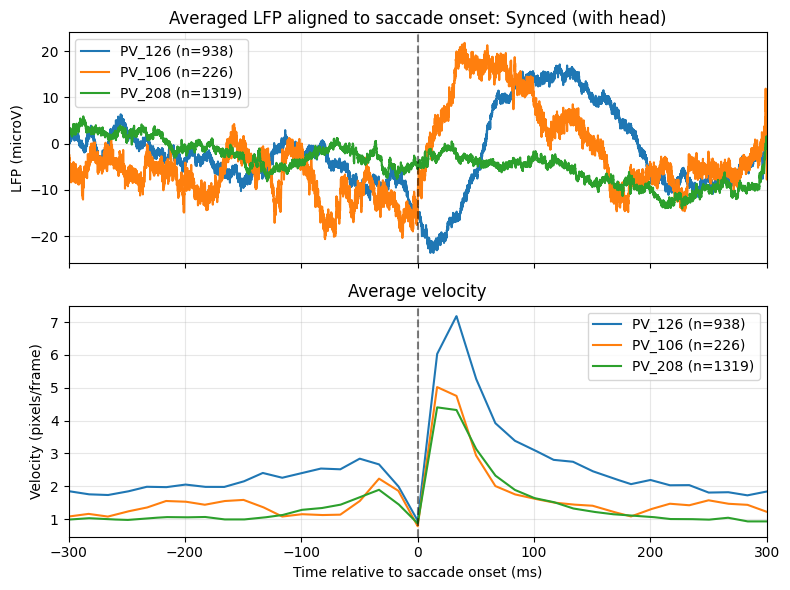

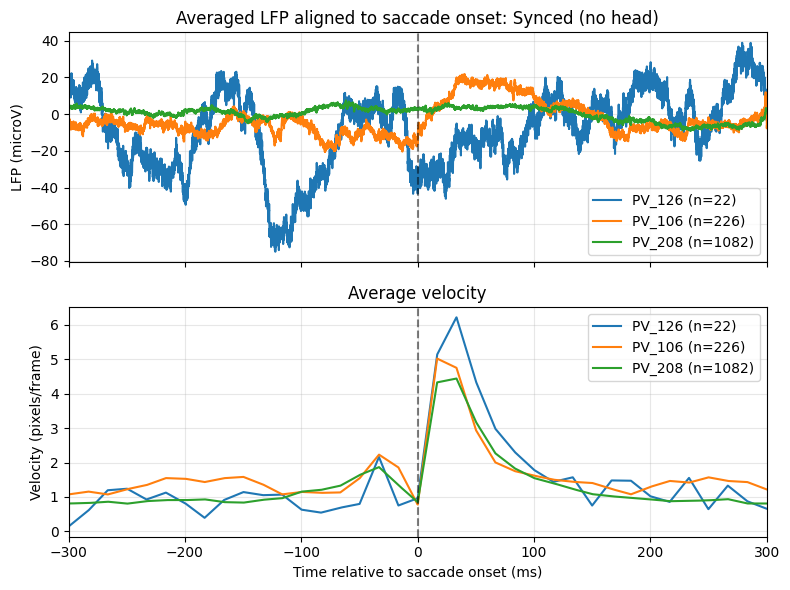

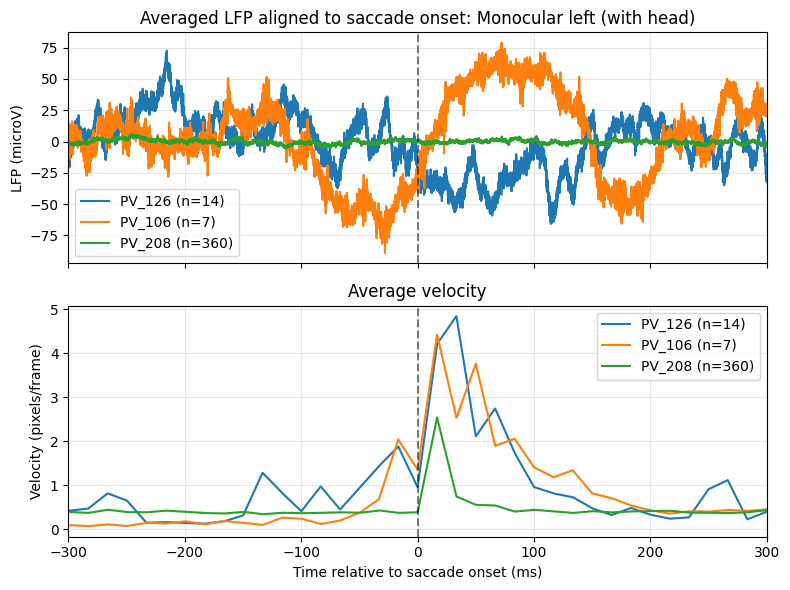

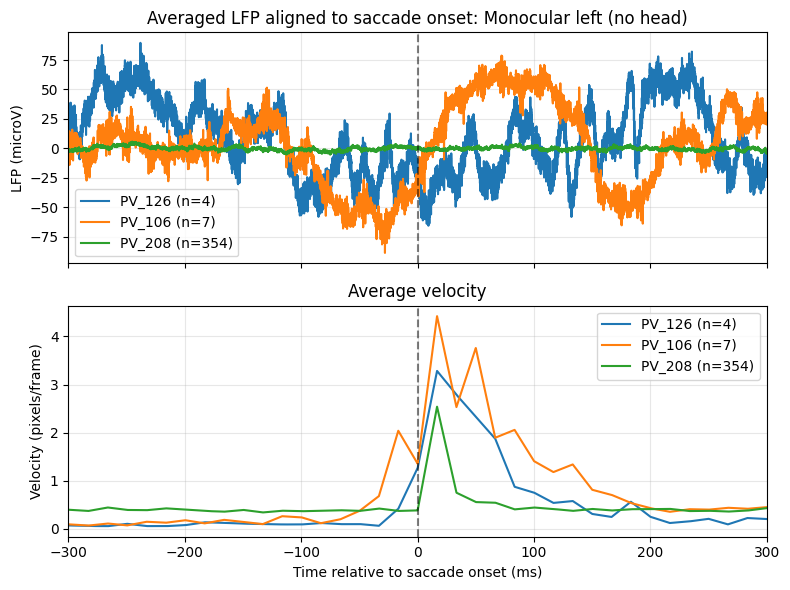

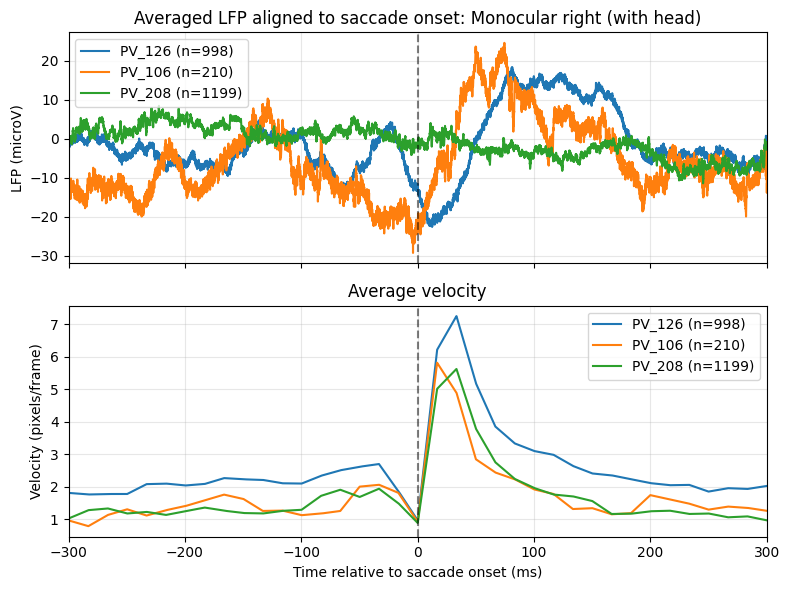

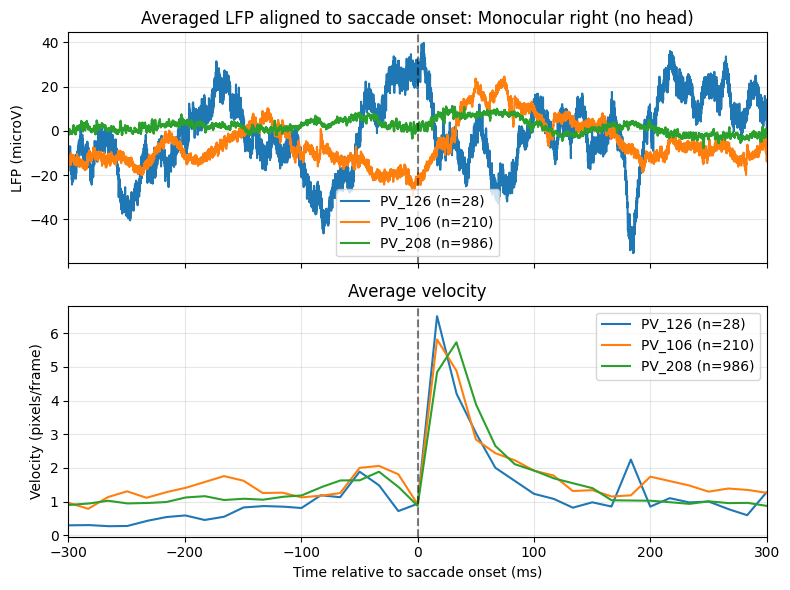

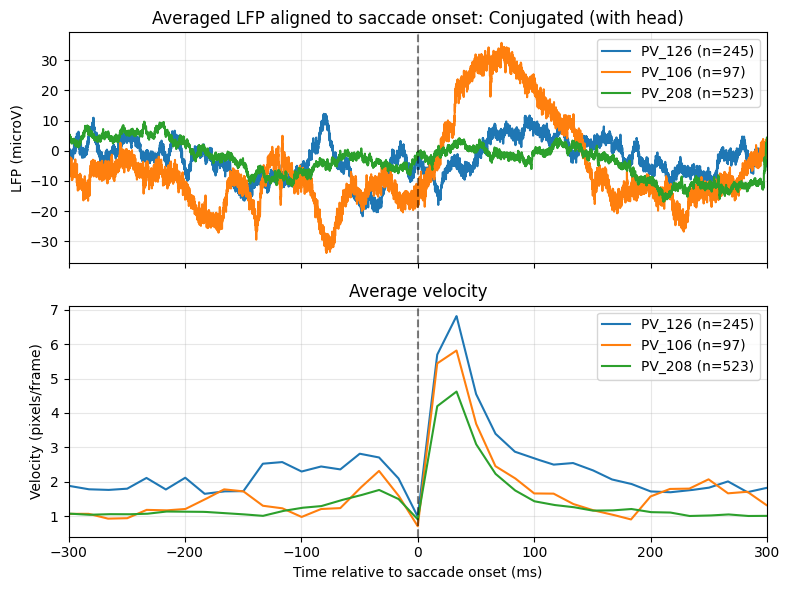

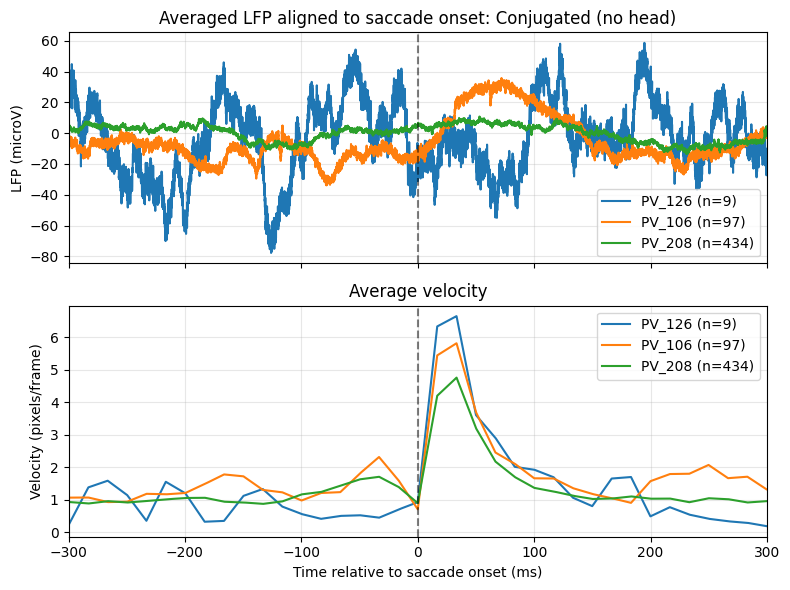

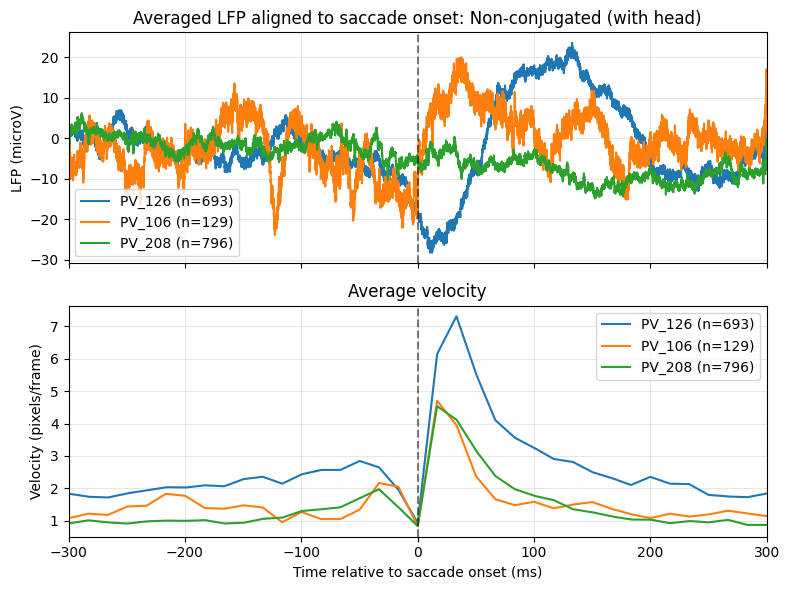

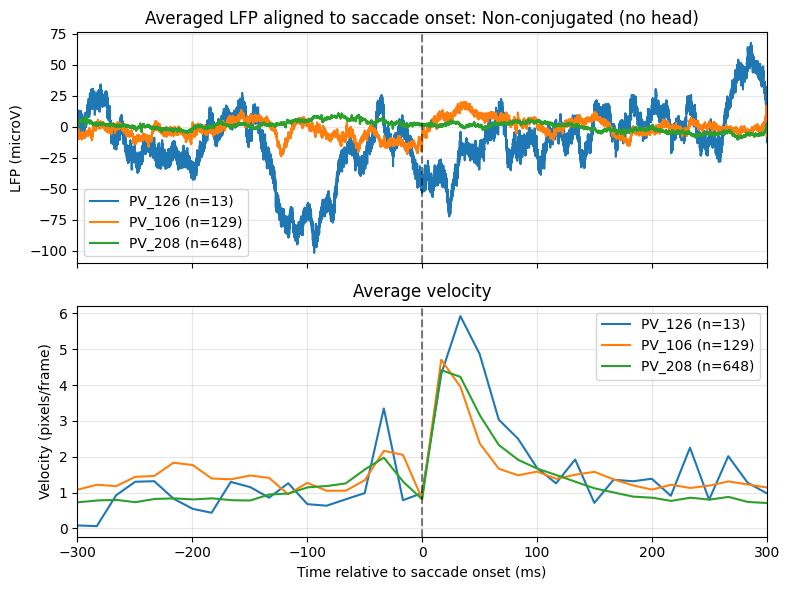

In [8]:
for name, df in filtered_collections:
    mean_lfp_per_animal = mean_lfp_by_filter[name]
    if not mean_lfp_per_animal:
        continue
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    
    # LFP plot
    ax_lfp = axes[0]
    for animal, lfp_data in mean_lfp_per_animal.items():
        t_rel = lfp_data[0]
        lfp = lfp_data[1]
        n_events = lfp_data[2] if len(lfp_data) > 2 else len(df[df["animal"] == animal])
        ax_lfp.plot(t_rel, lfp, label=f"{animal} (n={n_events})")
    ax_lfp.axvline(0, color="k", ls="--", alpha=0.5)
    ax_lfp.set_ylabel("LFP (microV)")
    ax_lfp.set_title(f"Averaged LFP aligned to saccade onset: {name}")
    ax_lfp.legend()
    ax_lfp.set_xlim(-half_window_ms, half_window_ms)
    ax_lfp.grid(True, alpha=0.3)
    
    # Velocity plot - use filtered rows if available
    ax_vel = axes[1]
    # Build filtered collection for velocity (use valid_rows_df from LFP extraction)
    df_filtered_for_vel = df.copy()
    if lfp_noise_filter_std is not None:
        # Reconstruct filtered dataframe from valid_rows_df
        valid_rows_list = []
        for animal, lfp_data in mean_lfp_per_animal.items():
            if len(lfp_data) > 3:
                valid_rows_df = lfp_data[3]
                if not valid_rows_df.empty:
                    valid_rows_list.append(valid_rows_df)
        if valid_rows_list:
            df_filtered_for_vel = pd.concat(valid_rows_list, ignore_index=True)
    
    mean_velocity_per_animal = extract_mean_velocity_per_animal(
        df_filtered_for_vel, block_dict, window_ms, half_window_ms, animals,
        t_rel_ms_target=mean_lfp_per_animal[list(mean_lfp_per_animal.keys())[0]][0] if mean_lfp_per_animal else None
    )
    for animal, vel_data in mean_velocity_per_animal.items():
        t_rel, velocity = vel_data
        n_events_vel = mean_lfp_per_animal[animal][2] if animal in mean_lfp_per_animal else len(df_filtered_for_vel[df_filtered_for_vel["animal"] == animal])
        ax_vel.plot(t_rel, velocity, label=f"{animal} (n={n_events_vel})")
    ax_vel.axvline(0, color="k", ls="--", alpha=0.5)
    ax_vel.set_xlabel("Time relative to saccade onset (ms)")
    ax_vel.set_ylabel("Velocity (pixels/frame)")
    ax_vel.set_title("Average velocity")
    ax_vel.legend()
    ax_vel.set_xlim(-half_window_ms, half_window_ms)
    ax_vel.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()

## Custom LFP average export (single animal, selected electrodes and conditions)

Choose **one animal**, a **list of electrode channels**, and a **list of (name, dataframe) pairs** for differently filtered saccade collections. The next cells will produce a **high-quality PDF** with one averaged LFP plot per (condition × electrode). For example: 2 conditions and 2 electrodes → 4 plots.

In [9]:
# --- User choices for custom LFP export ---
# Pick one animal (must be in the pipeline's inferred animals)
selected_animal = "PV_208"  # e.g. animals[0]

# OE channel numbers for LFP (one row per electrode in the output figure)
electrodes = [1, 15]

# List of (label, dataframe) for each saccade condition (use your pre-filtered dfs)
# Example: [("condition_A", df1), ("condition_B", df2)] — each becomes a column in the PDF
saccade_collections_custom = [
    ("Synced (with head)", synced_with_head),
    ("Synced (no head)", synced_no_head),
]

# LFP noise filtering (applied to custom export): set to None to disable, or a float threshold
lfp_noise_filter_std_custom = lfp_noise_filter_std  # Use same as global, or override here

# Where to save the PDF: set a path here, or leave None to auto-generate a unique name (animal + blocks)
pdf_save_path = None  # e.g. Path(export_dir) / "my_custom.pdf"
if pdf_save_path is None:
    _animal_blocks = block_lists[animals.index(selected_animal)]
    _blocks_str = "_".join(map(str, sorted(_animal_blocks)))
    _base = f"lfp_average_{selected_animal}_blocks_{_blocks_str}.pdf"
    pdf_save_path = (export_dir / _base) if export_dir.exists() else Path(_base)
if pdf_save_path:
    print(f"PDF will be saved to: {pdf_save_path}")

PDF will be saved to: D:\sample_data_for_eye_repo\analysis\saccade_collections\lfp_average_PV_208_blocks_19.pdf


In [ ]:
# Build mean LFP per (condition, electrode) for the selected animal only, then save to PDF
from matplotlib.backends.backend_pdf import PdfPages

if not pdf_save_path:
    raise ValueError("Set pdf_save_path or choose a file in the previous cell.")

# If pdf_save_path is a directory, write the auto-named file inside it (avoids PermissionError)
if pdf_save_path.is_dir():
    _animal_blocks = block_lists[animals.index(selected_animal)]
    _blocks_str = "_".join(map(str, sorted(_animal_blocks)))
    _fname = f"lfp_average_{selected_animal}_blocks_{_blocks_str}.pdf"
    pdf_save_path = pdf_save_path / _fname
    print(f"Using path: {pdf_save_path}")

# Filter each collection to selected animal and compute mean LFP per electrode
n_conditions = len(saccade_collections_custom)
n_electrodes = len(electrodes)
# (cond_name, ch) -> (t_rel_ms, mean_lfp, n_valid_events)
results_lfp = {}
# (cond_name) -> (t_rel_ms, mean_velocity, n_valid_events)
results_velocity = {}

print(f"Processing {n_conditions} condition(s) × {n_electrodes} electrode(s) = {n_conditions * n_electrodes} LFP extraction(s) + {n_conditions} velocity extraction(s)")
# Calculate total saccades safely - use indexing instead of unpacking to avoid errors
total_saccades = 0
for item in saccade_collections_custom:
    if len(item) >= 2:
        df = item[1]  # Get dataframe (second element of tuple)
        total_saccades += len(df[df['animal'] == selected_animal])
print(f"Total saccades to process: {total_saccades}")

for cond_idx, item in enumerate(tqdm(saccade_collections_custom, desc="Conditions", leave=True)):
    # Unpack safely using indexing
    cond_name = item[0]
    df = item[1]
    df_animal = df[df["animal"] == selected_animal]
    if df_animal.empty:
        print(f"Warning: no rows for animal {selected_animal} in condition '{cond_name}'; skipping.")
        continue
    
    # Extract LFP for each electrode
    valid_rows_df_combined = None
    for ch_idx, ch in enumerate(tqdm(electrodes, desc=f"  {cond_name} electrodes", leave=False)):
        mean_lfp_dict = extract_mean_lfp_per_animal(
            df_animal, block_dict, [ch], window_ms, half_window_ms, [selected_animal],
            noise_filter_std=lfp_noise_filter_std_custom,
            desc_prefix=f"LFP ch{ch}"
        )
        if selected_animal not in mean_lfp_dict:
            print(f"Warning: no LFP for {selected_animal} ch {ch} in '{cond_name}'; skipping.")
            continue
        lfp_data = mean_lfp_dict[selected_animal]
        t_rel = lfp_data[0]
        mean_lfp = lfp_data[1]
        n_valid = lfp_data[2] if len(lfp_data) > 2 else len(df_animal)
        results_lfp[(cond_name, ch)] = (t_rel, mean_lfp, n_valid)
        
        # Store valid_rows_df from first electrode (all electrodes use same filtering)
        if valid_rows_df_combined is None and len(lfp_data) > 3:
            valid_rows_df_combined = lfp_data[3]
    
    # Extract velocity - use filtered rows if filtering was applied
    df_animal_for_vel = df_animal.copy()
    if lfp_noise_filter_std_custom is not None and valid_rows_df_combined is not None and not valid_rows_df_combined.empty:
        df_animal_for_vel = valid_rows_df_combined
    
    # Get time grid from first available LFP result
    t_rel_target = None
    if electrodes and (cond_name, electrodes[0]) in results_lfp:
        t_rel_target = results_lfp[(cond_name, electrodes[0])][0]
    
    mean_velocity_dict = extract_mean_velocity_per_animal(
        df_animal_for_vel, block_dict, window_ms, half_window_ms, [selected_animal],
        t_rel_ms_target=t_rel_target,
        desc_prefix=f"Velocity {cond_name}"
    )
    if selected_animal in mean_velocity_dict:
        vel_data = mean_velocity_dict[selected_animal]
        t_rel_vel, mean_velocity = vel_data
        # Use filtered count from LFP (same filtering applies)
        n_valid_vel = results_lfp.get((cond_name, electrodes[0]), (None, None, len(df_animal)))[2] if electrodes else len(df_animal)
        results_velocity[cond_name] = (t_rel_vel, mean_velocity, n_valid_vel)

if not results_lfp:
    raise ValueError("No LFP data for the selected animal/electrodes/conditions. Check filters and block_dict.")

# Layout: rows = electrodes + 1 velocity row, columns = filtered conditions
# Each cell contains LFP plot on top, velocity plot on bottom
fig, axes = plt.subplots(
    n_electrodes + 1, n_conditions,
    figsize=(4 * n_conditions, 3.5 * (n_electrodes + 1)),
    squeeze=False,
)

# Plot LFP for each electrode
for row, ch in enumerate(electrodes):
    for col, item in enumerate(saccade_collections_custom):
        cond_name = item[0]  # Get condition name using indexing
        df_item = item[1]    # Get dataframe for reference
        ax = axes[row, col]
        key = (cond_name, ch)
        if key in results_lfp:
            t_rel, mean_lfp, n_valid = results_lfp[key]
            ax.plot(t_rel, mean_lfp, color="C0")
            # Get df_animal for this condition to calculate filter note
            df_animal_for_note = df_item[df_item["animal"] == selected_animal] if 'animal' in df_item.columns else pd.DataFrame()
            total_for_cond = len(df_animal_for_note) if len(df_animal_for_note) > 0 else n_valid
            filter_note = f" (filtered: {n_valid}/{total_for_cond})" if lfp_noise_filter_std_custom is not None and total_for_cond > n_valid else ""
            ax.set_title(f"{cond_name}\nCh {ch} (n={n_valid}{filter_note})")
        else:
            ax.set_title(f"{cond_name}\nCh {ch} (no data)")
        ax.axvline(0, color="k", ls="--", alpha=0.5)
        if row == n_electrodes - 1:
            ax.set_xlabel("Time rel. saccade onset (ms)")
        ax.set_ylabel("LFP (µV)")
        ax.set_xlim(-half_window_ms, half_window_ms)
        ax.grid(True, alpha=0.3)

# Plot velocity in bottom row
for col, item in enumerate(saccade_collections_custom):
    cond_name = item[0]  # Get condition name using indexing
    df = item[1]         # Get dataframe using indexing
    ax = axes[n_electrodes, col]
    if cond_name in results_velocity:
        t_rel, mean_velocity, n_valid = results_velocity[cond_name]
        ax.plot(t_rel, mean_velocity, color="C1")
        filter_note = f" (filtered: {n_valid}/{len(df[df['animal'] == selected_animal])})" if lfp_noise_filter_std_custom is not None and n_valid < len(df[df['animal'] == selected_animal]) else ""
        ax.set_title(f"Average velocity{filter_note}")
    else:
        ax.set_title("Average velocity (no data)")
    ax.axvline(0, color="k", ls="--", alpha=0.5)
    ax.set_xlabel("Time rel. saccade onset (ms)")
    ax.set_ylabel("Velocity (pixels/frame)")
    ax.set_xlim(-half_window_ms, half_window_ms)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# PDF metadata: internal name with animal and blocks for identification
_animal_blocks = block_lists[animals.index(selected_animal)]
_pdf_title = f"LFP average — {selected_animal} blocks {_animal_blocks}"
with PdfPages(pdf_save_path) as pdf:
    _meta = pdf.infodict()
    _meta["Title"] = _pdf_title
    pdf.savefig(fig, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {len(results_lfp)} LFP average plot(s) + {len(results_velocity)} velocity plot(s) to {pdf_save_path}")

Computing average spectrograms for each filtered collection...
Note: Sampling rate will be auto-detected from the data if not specified.

Processing: Synced (with head)
    PV_126: Found 938 valid saccades


Spectrogram PV_126:   0%|          | 0/1 [00:00<?, ?it/s]

sample removed for window #22
sample removed for window #25
sample removed for window #26
sample removed for window #36
sample removed for window #39
sample removed for window #46
sample removed for window #60
sample removed for window #66
sample removed for window #85
sample removed for window #87
sample removed for window #88
sample removed for window #94
sample removed for window #98
sample removed for window #110
sample removed for window #114
sample removed for window #130
sample removed for window #149
sample removed for window #168
sample removed for window #179
sample removed for window #192
sample removed for window #200
sample removed for window #218
sample removed for window #220
sample removed for window #236
sample removed for window #244
sample removed for window #249
sample removed for window #290
sample removed for window #304
sample removed for window #323
sample removed for window #326
sample removed for window #334
sample removed for window #347
sample removed for wi

Spectrogram PV_126:   0%|          | 0/1 [00:01<?, ?it/s, detected_fs=20000.0 Hz, n_samples=8e+4]

      PV_126: Extracted data shape: (1, 938, 80000), expecting 938 windows
      PV_126: Detected sampling rate: 20000.0 Hz (n_samples=80000, window_ms=4000)


...

Spectrogram PV_208:   0%|          | 0/1 [00:00<?, ?it/s]

sample removed for window #9
sample removed for window #53
sample removed for window #58
sample removed for window #69
sample removed for window #76
sample removed for window #81
sample removed for window #82
sample removed for window #91
sample removed for window #95
sample removed for window #97
sample removed for window #98
sample removed for window #103
sample removed for window #111
sample removed for window #122
sample removed for window #139
sample removed for window #148
sample removed for window #168
sample removed for window #169
sample removed for window #173
sample removed for window #179
sample removed for window #191
sample removed for window #201
sample removed for window #203
sample removed for window #205
sample removed for window #206
sample removed for window #214
sample removed for window #218
sample removed for window #232
sample removed for window #249
sample removed for window #265
sample removed for window #273
sample removed for window #297
sample removed for w

Spectrogram PV_208:   0%|          | 0/1 [00:00<?, ?it/s, detected_fs=20000.0 Hz, n_samples=8e+4]

      PV_208: Extracted data shape: (1, 648, 80000), expecting 648 windows
      PV_208: Detected sampling rate: 20000.0 Hz (n_samples=80000, window_ms=4000)


    PV_208: Successfully computed 648 spectrograms
  PV_126: 13 events, freq range: 0.0-10000.0 Hz
  PV_106: 129 events, freq range: 0.0-10000.0 Hz
  PV_208: 648 events, freq range: 0.0-10000.0 Hz

Plotting average spectrograms...


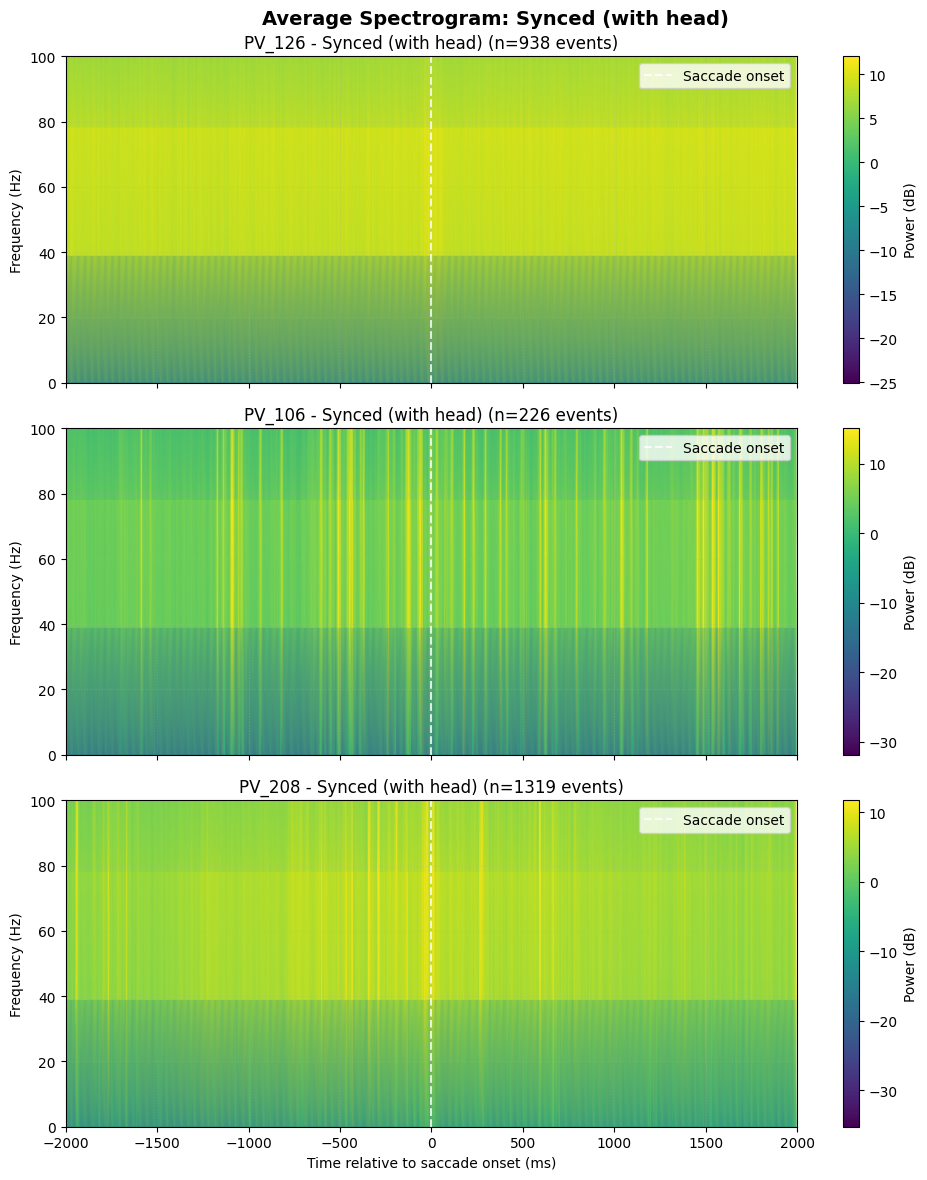

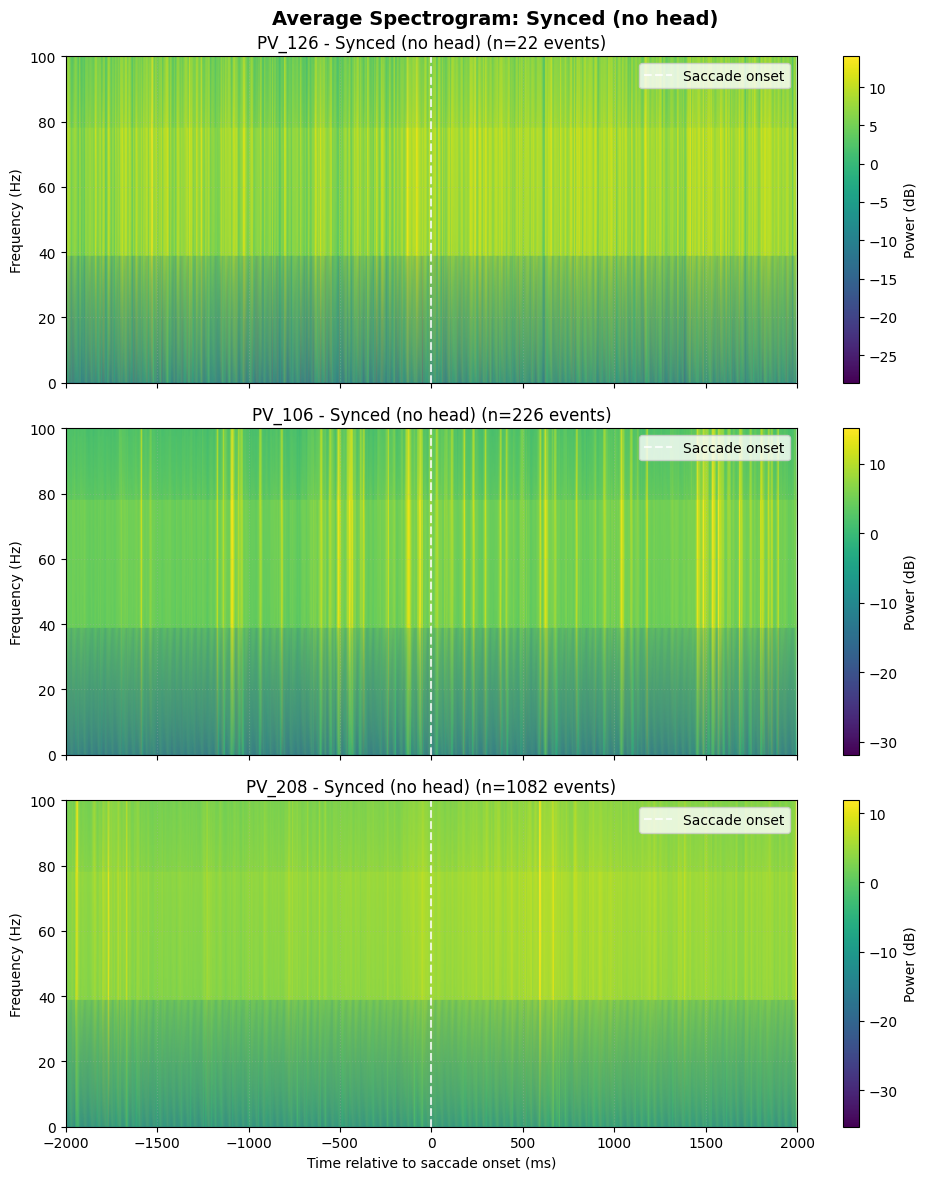

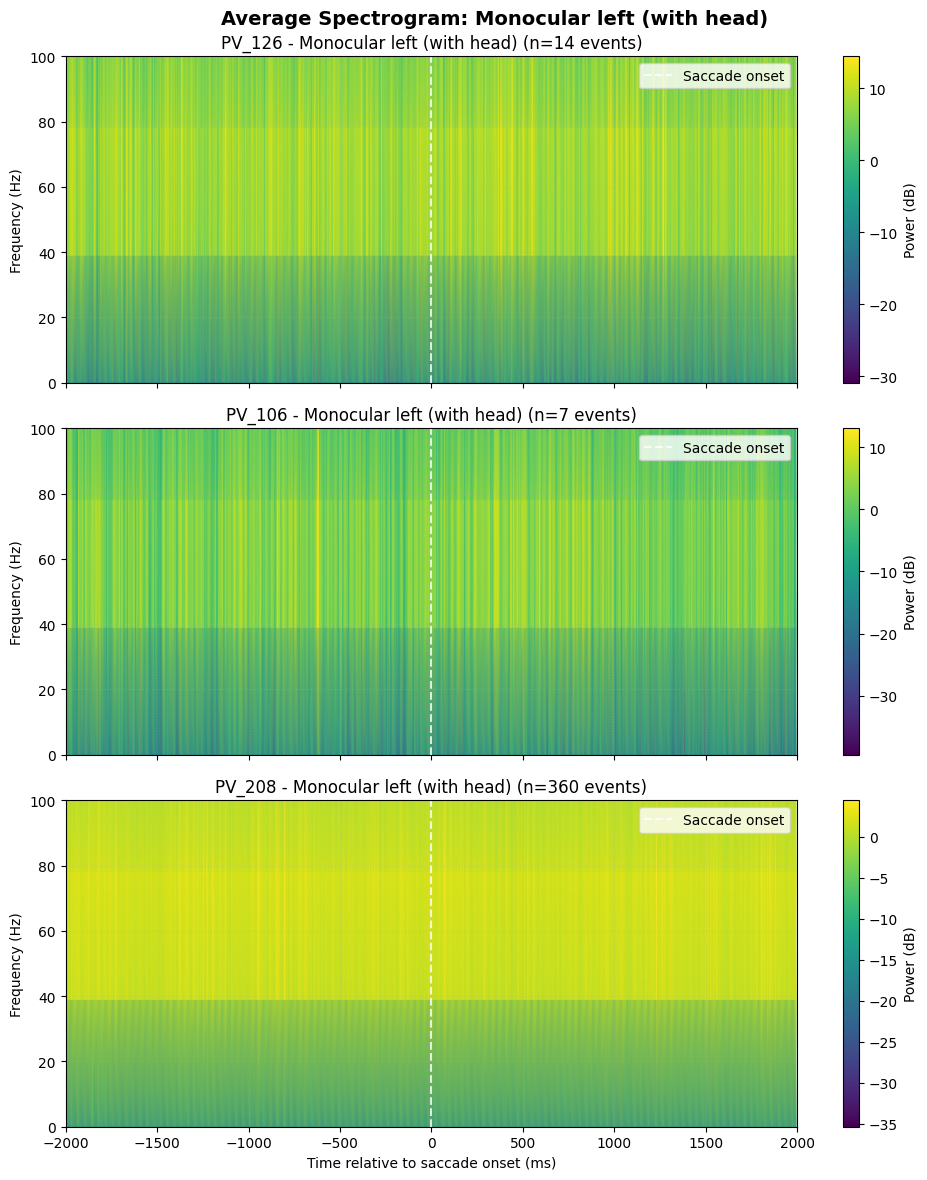

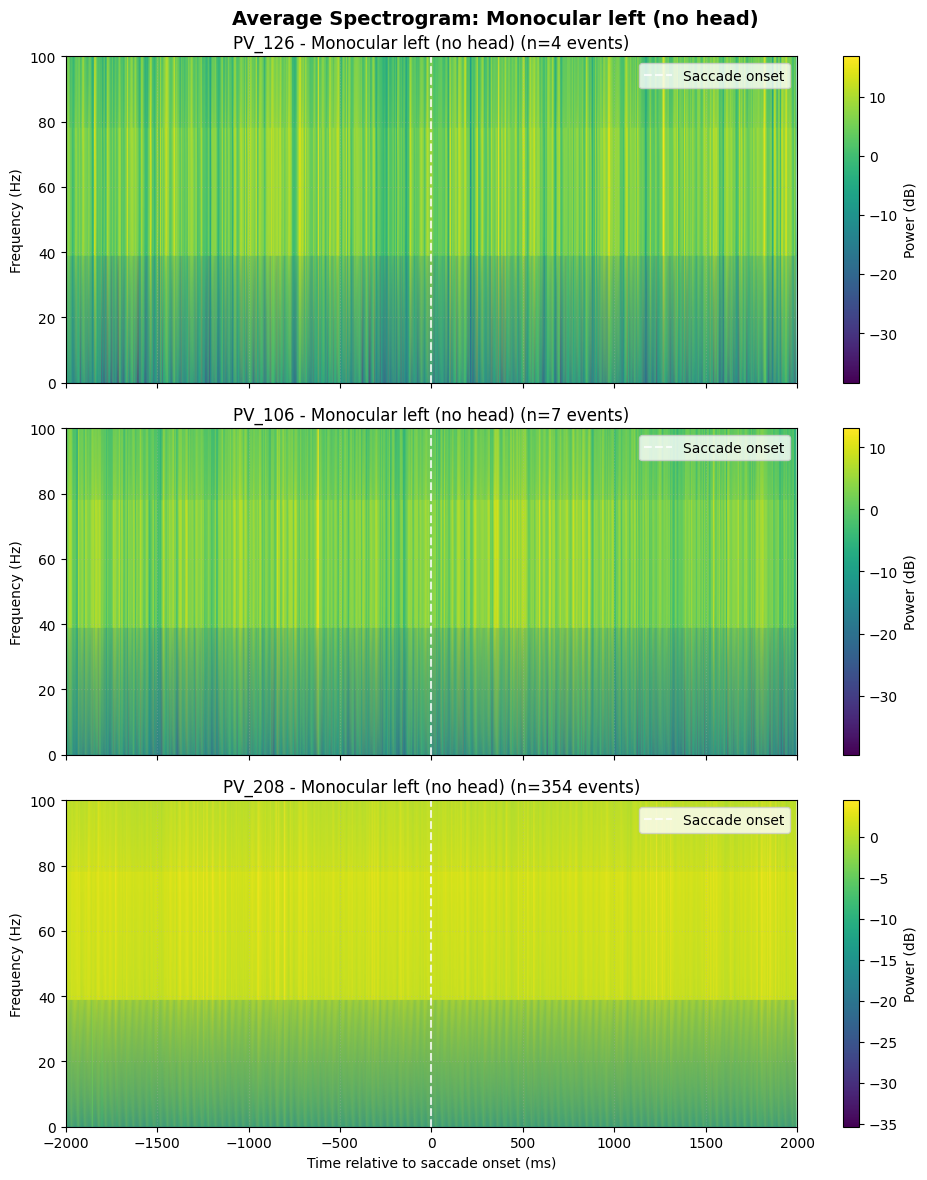

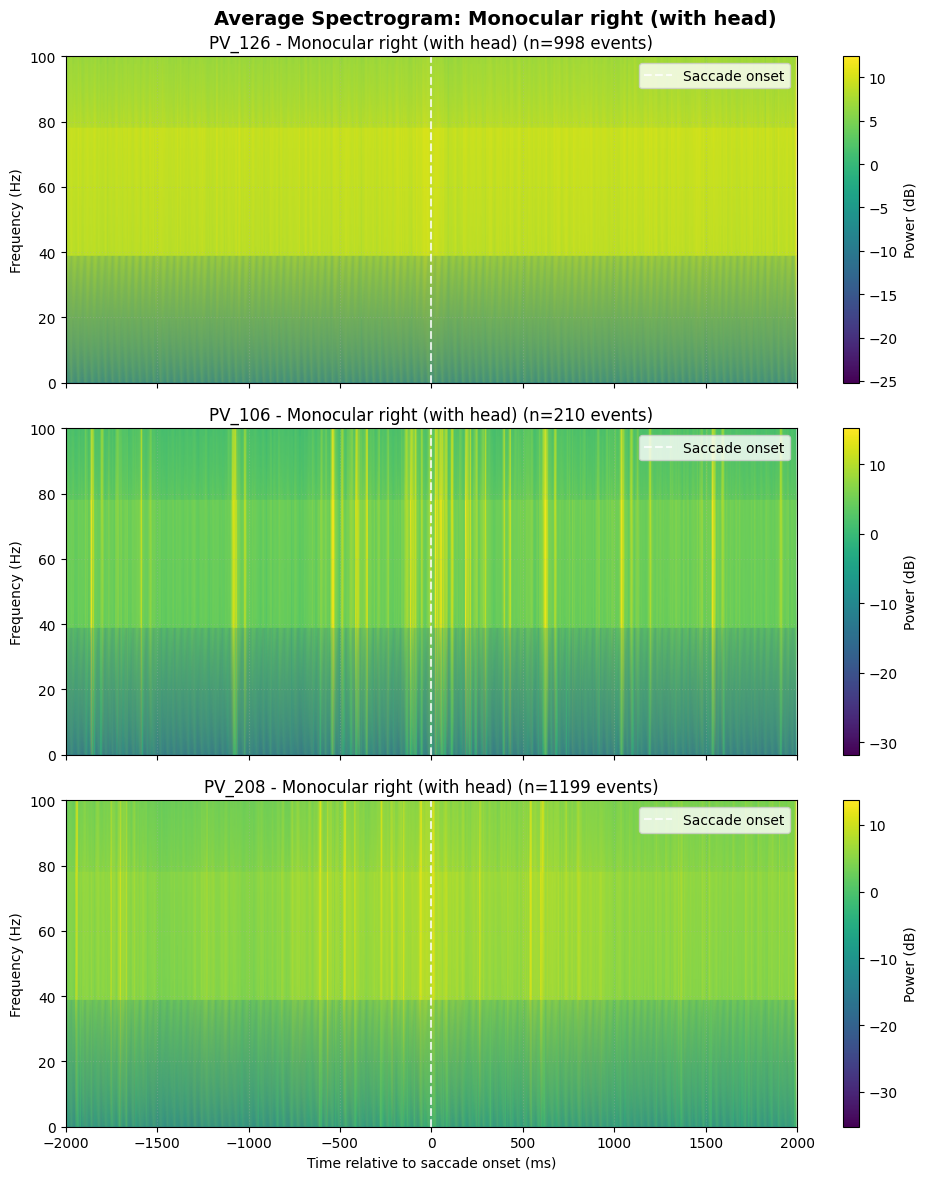

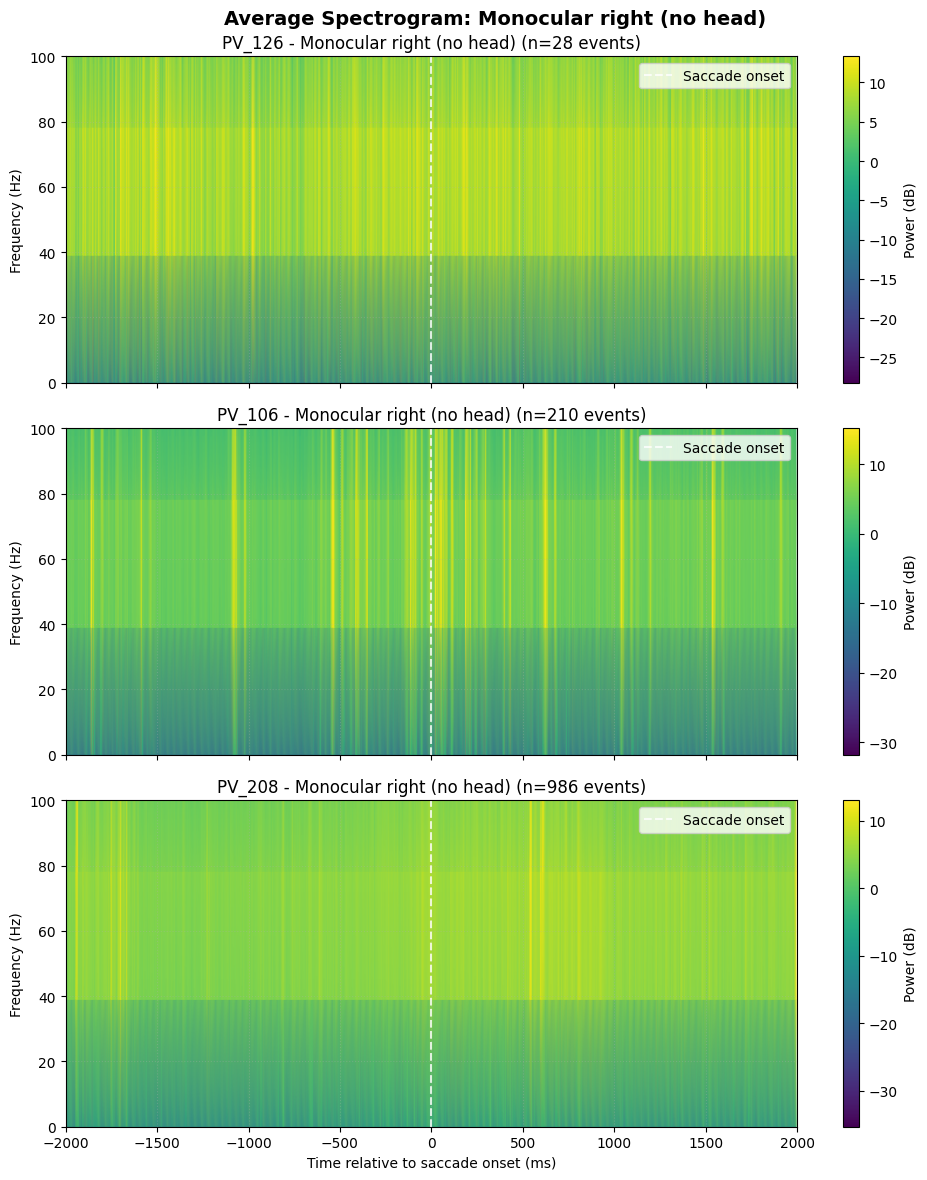

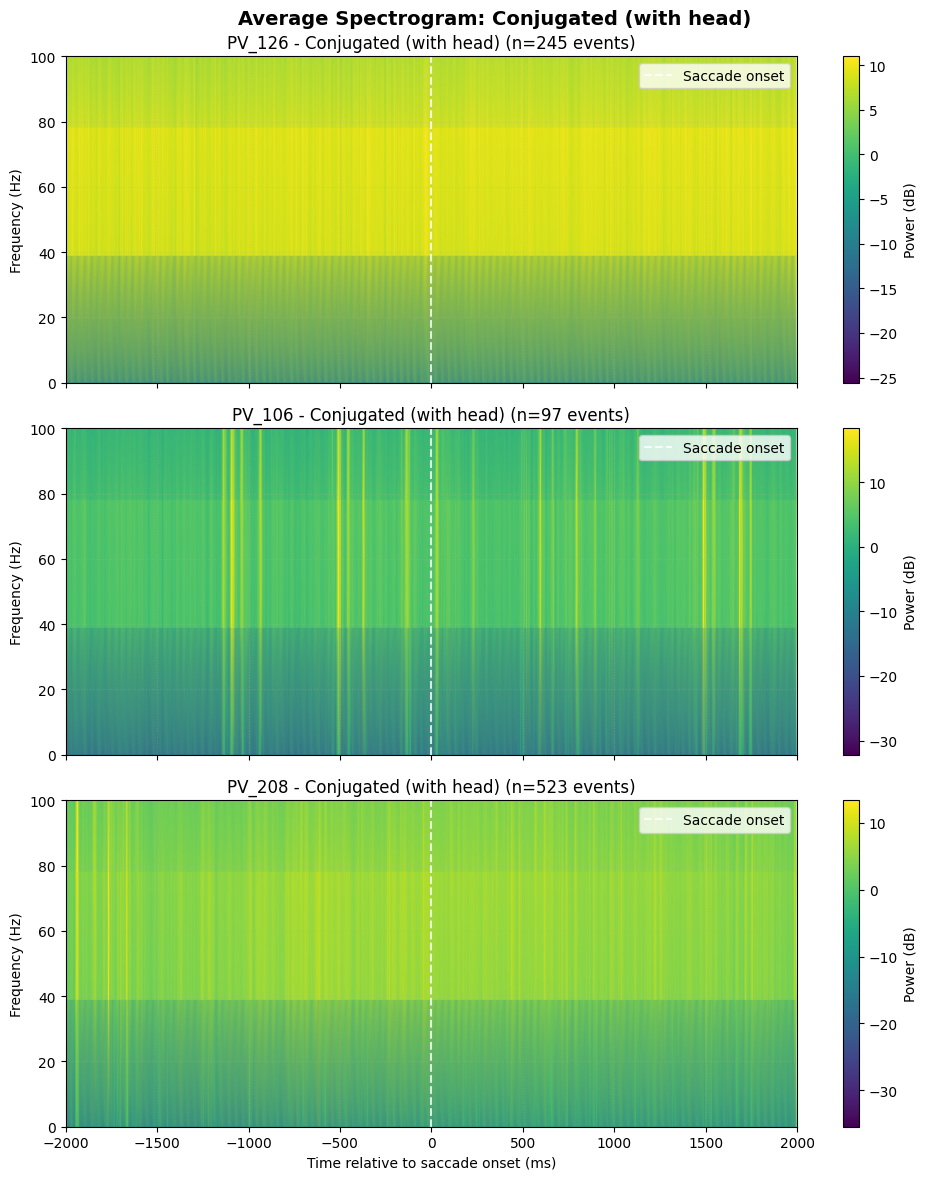

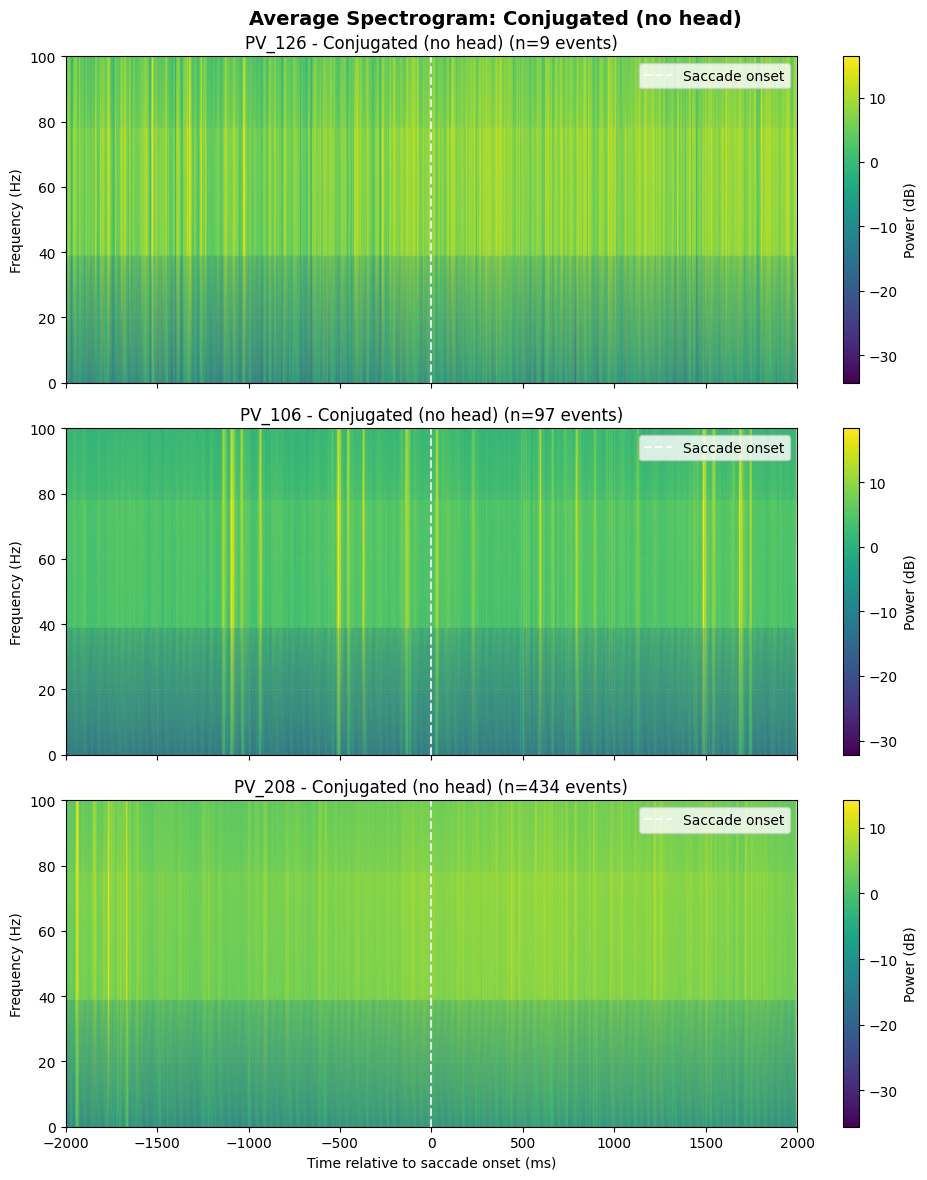

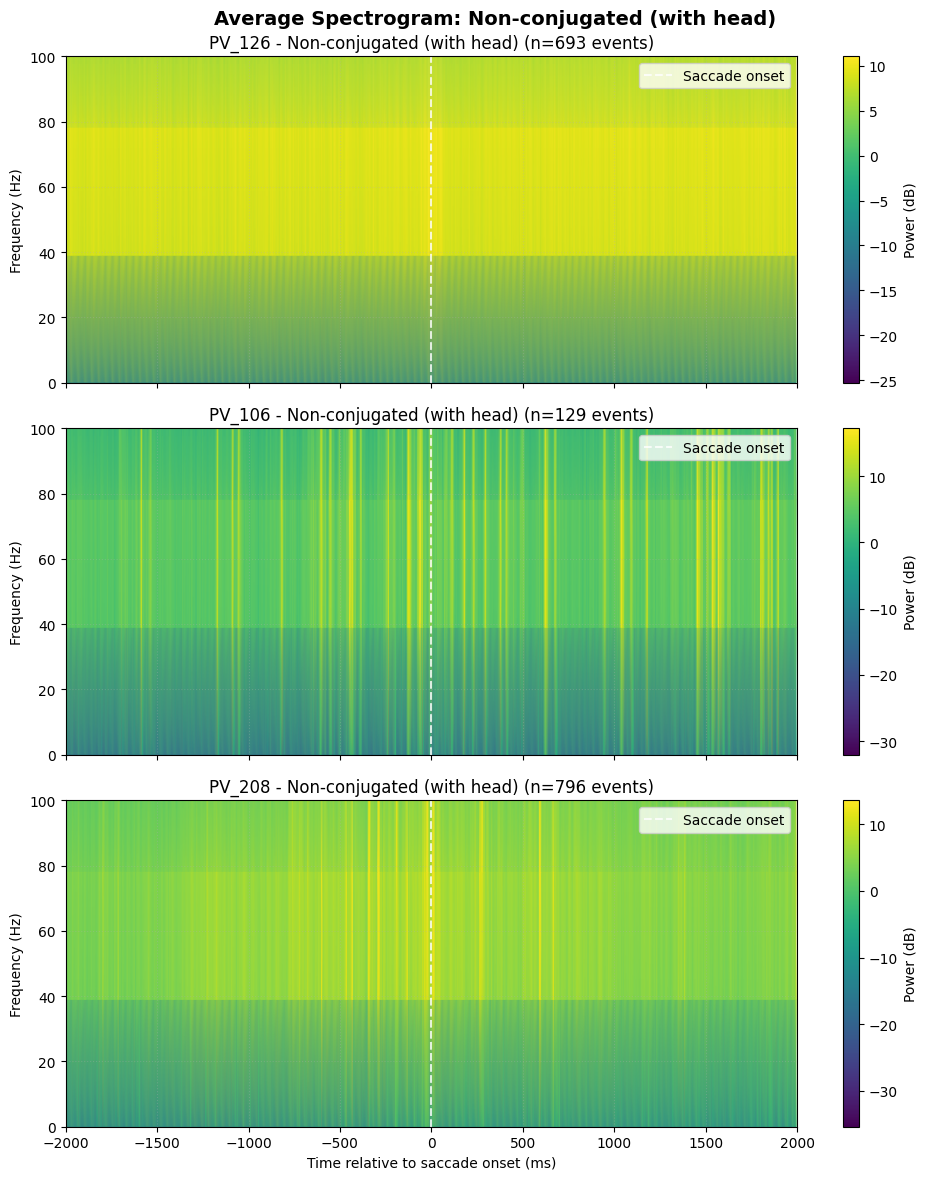

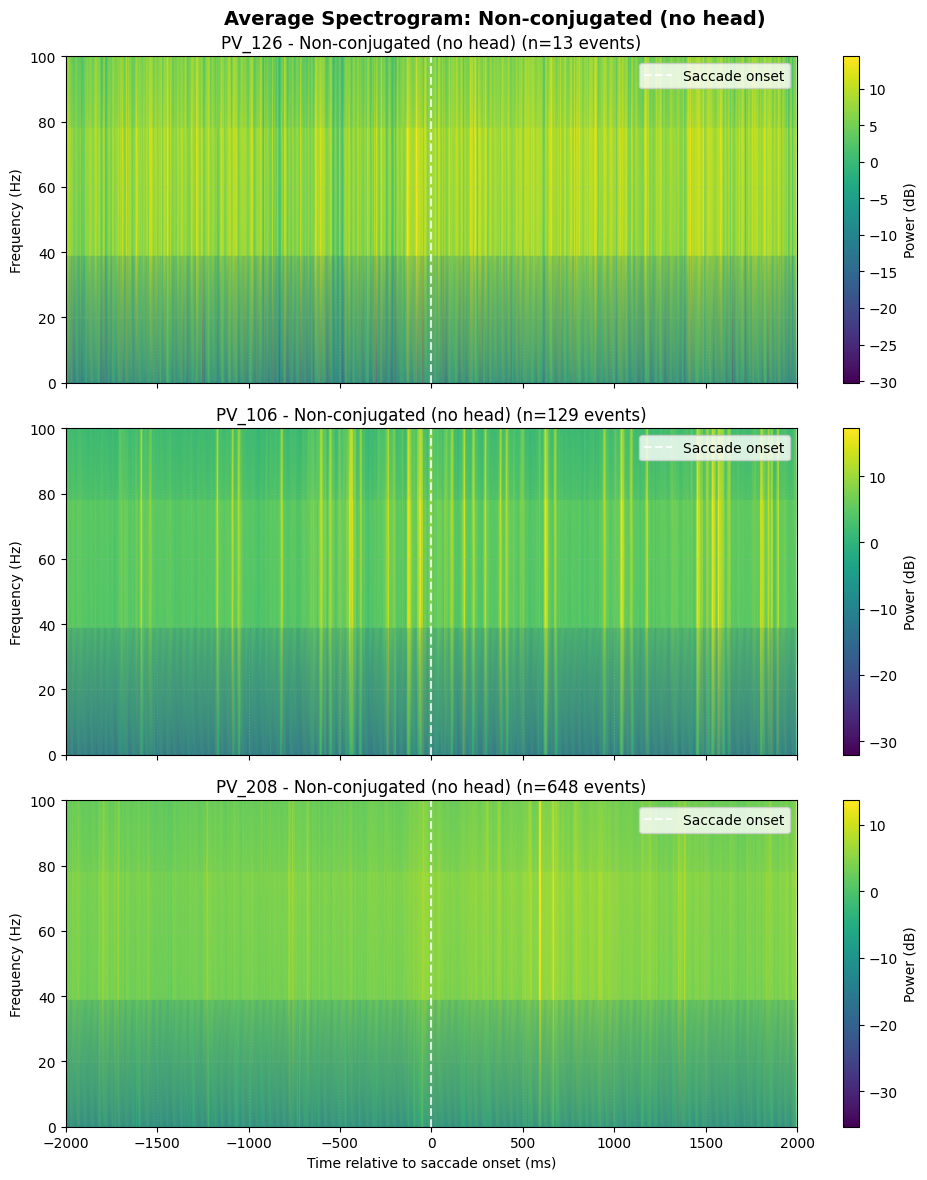


Spectrogram analysis complete!


In [10]:
# =============================================================================
# SPECTROGRAM ANALYSIS: Average spectrogram aligned to saccade onset
# =============================================================================
"""
This cell computes average spectrograms for LFP signals aligned to saccade onset.

METHODOLOGY:
We compute spectrograms for each individual saccade event, then average the 
spectrograms (not average LFP first, then compute spectrogram). This is the 
standard approach because:
1. Spectrograms are power estimates (non-linear transformation)
2. Averaging power preserves frequency-specific information
3. Averaging LFP first can lose phase relationships and reduce frequency resolution
4. This matches standard neuroscience practice (e.g., ERSP - Event-Related Spectral Perturbation)

The window is ±2 seconds around saccade onset (centered at 0).
"""

from scipy import signal
import matplotlib.colors as mcolors

# Configuration
spectrogram_window_ms = 4000  # ±2 seconds = 4 seconds total
spectrogram_half_window_ms = spectrogram_window_ms / 2
# Sampling rate will be auto-detected from data, but you can override here if needed
spectrogram_fs = None  # If None, will be computed from first window: fs = n_samples / (window_ms / 1000)
# correct the nperseg for the proper length to 
nperseg = 256  # Window length for spectrogram (samples) - adjust for desired frequency resolution
noverlap = nperseg // 2  # 50% overlap
nfft = 512  # FFT length (can be larger than nperseg for zero-padding)
max_freq_display = 100  # Maximum frequency to display in plots (Hz) - adjust as needed

def extract_spectrogram_per_animal(collection_df, block_dict, lfp_channels, window_ms, half_window_ms, 
                                    animals, fs, nperseg, noverlap, nfft, noise_filter_std=None):
    """
    Extract LFP windows and compute average spectrogram per animal.
    
    Returns dict: animal -> (frequencies, times, average_spectrogram, n_valid_events)
    """
    from collections import defaultdict
    
    spectrogram_per_animal = {}
    
    for animal in animals:
        rows = collection_df[collection_df["animal"] == animal].copy()
        if rows.empty:
            continue
        
        # Group saccades by block for batch extraction
        rows["block_key"] = rows.apply(lambda r: _block_key(r["animal"], r["block"]), axis=1)
        
        # Collect all valid saccades
        saccade_info = []
        dur_ms_cache = {}
        
        for idx, r in rows.iterrows():
            block_key = r["block_key"]
            block = block_dict.get(block_key)
            if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
                continue
            
            # Cache duration
            if block_key not in dur_ms_cache:
                dur_ms_cache[block_key] = getattr(block.oe_rec, "recordingDuration_ms", None)
            
            onset_ms = float(r["saccade_on_ms"])
            start_ms = onset_ms - half_window_ms
            end_ms = onset_ms + half_window_ms
            
            dur_ms = dur_ms_cache[block_key]
            if dur_ms is not None and (start_ms < 0 or end_ms > dur_ms):
                continue
            
            saccade_info.append((idx, block_key, start_ms, r))
        
        if not saccade_info:
            print(f"    Warning: No valid saccades found for {animal} (all filtered out)")
            continue
        
        print(f"    {animal}: Found {len(saccade_info)} valid saccades")
        
        # Group by block for batch extraction
        block_groups = defaultdict(list)
        for idx, block_key, start_ms, r in saccade_info:
            block_groups[block_key].append((idx, start_ms, r))
        
        # Extract windows and compute spectrograms
        spectrograms = []
        valid_rows = []
        fs_detected = fs  # Will be updated from first window if fs is None
        freqs = None  # Will be set from first successful spectrogram
        times = None  # Will be set from first successful spectrogram
        
        pbar = tqdm(block_groups.items(), desc=f"Spectrogram {animal}", leave=False)
        for block_key, saccade_list in pbar:
            block = block_dict[block_key]
            if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
                continue
            
            # Get start times for batch extraction
            start_times_ms = np.array([start_ms for _, start_ms, _ in saccade_list], dtype=float)
            start_arr = np.atleast_2d(np.array(start_times_ms, dtype=float))  # Shape: [1, n_windows]
            
            try:
                # Batch extract LFP data (matching format from existing LFP extraction)
                data, ts = block.oe_rec.get_data(
                    lfp_channels,
                    start_arr,
                    window_ms,
                    convert_microvolts=True,
                    return_timestamps=True,
                    repress_output=False,
                )
            except Exception as e:
                pbar.set_postfix({"error": str(e)[:30]})
                continue
            
            if data is None or data.size == 0:
                pbar.set_postfix({"error": "No data returned"})
                if len(spectrograms) == 0:  # Only print for first block
                    print(f"      Warning: No data returned for block {block_key} (animal: {animal})")
                continue
            
            n_windows_batch = data.shape[1] if len(data.shape) > 1 else 1
            n_channels_batch = data.shape[0]
            
            if len(spectrograms) == 0 and len(block_groups) > 0:  # Debug first block
                print(f"      {animal}: Extracted data shape: {data.shape}, expecting {len(saccade_list)} windows")
            
            windows_processed = 0
            for batch_idx, (orig_idx, start_ms, r) in enumerate(saccade_list):
                if batch_idx >= n_windows_batch:
                    continue
                
                # Extract window for this saccade
                if n_channels_batch == 1:
                    win = data[0, batch_idx, :]
                else:
                    # Average across channels
                    win = np.nanmean(data[:, batch_idx, :], axis=0)
                
                windows_processed += 1
                
                # Check if window is valid
                if len(win) == 0:
                    if windows_processed == 1:  # Only print for first window to avoid spam
                        print(f"      Warning: Empty window extracted for {animal}")
                    continue
                
                # Apply noise filter if specified
                if noise_filter_std is not None:
                    win_std = np.nanstd(win)
                    if win_std > noise_filter_std:
                        continue
                
                # Remove NaN values (replace with 0 or interpolate)
                if np.any(np.isnan(win)):
                    win = np.nan_to_num(win, nan=0.0)
                
                # Auto-detect sampling rate from first window if not specified
                if fs_detected is None or fs_detected <= 0:
                    n_samples = len(win)
                    if n_samples == 0:
                        pbar.set_postfix({"error": "Empty window"})
                        continue
                    fs_detected = n_samples / (window_ms / 1000.0)  # samples per second
                    if windows_processed == 1:  # Only print for first window
                        print(f"      {animal}: Detected sampling rate: {fs_detected:.1f} Hz (n_samples={n_samples}, window_ms={window_ms})")
                    pbar.set_postfix({"detected_fs": f"{fs_detected:.1f} Hz", "n_samples": n_samples})
                
                # Check if fs_detected is valid
                if fs_detected is None or fs_detected <= 0:
                    if windows_processed == 1:
                        print(f"      Error: Invalid sampling rate for {animal}")
                    continue
                
                # Compute spectrogram for this window
                try:
                    freqs_curr, times_curr, Sxx = signal.spectrogram(
                        win,
                        fs=fs_detected,
                        nperseg=nperseg,
                        noverlap=noverlap,
                        nfft=nfft,
                        mode='psd'  # Power spectral density
                    )
                    # Store freqs and times from first successful spectrogram
                    if freqs is None:
                        freqs = freqs_curr
                        times = times_curr
                    spectrograms.append(Sxx)
                    valid_rows.append(r)
                except Exception as e:
                    if len(spectrograms) == 0:  # Only print error for first failure
                        print(f"      Error computing spectrogram for {animal}: {e}")
                        print(f"        Window shape: {win.shape}, fs: {fs_detected}, nperseg: {nperseg}, noverlap: {noverlap}, nfft: {nfft}")
                        import traceback
                        print(f"        Traceback: {traceback.format_exc()}")
                    pbar.set_postfix({"spectrogram_error": str(e)[:30]})
                    continue
            
            if windows_processed > 0:
                pbar.set_postfix({"windows": windows_processed, "spectrograms": len(spectrograms)})
        
        pbar.close()
        
        if len(spectrograms) == 0 and len(saccade_info) > 0:
            print(f"    {animal}: Processed {len(saccade_info)} saccades but computed 0 spectrograms - check data extraction")
        
        if not spectrograms:
            print(f"    Warning: No valid spectrograms computed for {animal}")
            continue
        
        # Average spectrograms
        # All spectrograms should have same frequency bins, but times may differ slightly
        # Stack and average
        try:
            spectrogram_stack = np.stack(spectrograms)
            avg_spectrogram = np.nanmean(spectrogram_stack, axis=0)
            
            # Use frequencies and times from last spectrogram (they should all be the same)
            # Convert times to relative to saccade onset (centered at 0)
            if spectrograms:
                freqs_final = freqs
                times_final = times - half_window_ms / 1000  # Convert to seconds relative to onset
                n_valid = len(valid_rows)
                
                spectrogram_per_animal[animal] = (freqs_final, times_final, avg_spectrogram, n_valid, valid_rows)
                print(f"    {animal}: Successfully computed {n_valid} spectrograms")
        except Exception as e:
            print(f"    Error averaging spectrograms for {animal}: {e}")
            continue
    
    return spectrogram_per_animal

# Compute spectrograms for each filtered collection
print("Computing average spectrograms for each filtered collection...")
print("Note: Sampling rate will be auto-detected from the data if not specified.")
spectrogram_results = {}

for name, df in filtered_collections:
    print(f"\nProcessing: {name}")
    spectrogram_per_animal = extract_spectrogram_per_animal(
        df, block_dict, lfp_channels, 
        spectrogram_window_ms, spectrogram_half_window_ms,
        animals, spectrogram_fs, nperseg, noverlap, nfft,
        noise_filter_std=lfp_noise_filter_std
    )
    
    if spectrogram_per_animal:
        spectrogram_results[name] = spectrogram_per_animal
        for animal, (freqs, times, spec, n_events, _) in spectrogram_per_animal.items():
            print(f"  {animal}: {n_events} events, freq range: {freqs[0]:.1f}-{freqs[-1]:.1f} Hz")

# Plot spectrograms
print("\n" + "="*60)
print("Plotting average spectrograms...")
print("="*60)

for name, spec_dict in spectrogram_results.items():
    if not spec_dict:
        continue
    
    n_animals = len(spec_dict)
    fig, axes = plt.subplots(n_animals, 1, figsize=(10, 4 * n_animals), sharex=True, sharey=True)
    
    if n_animals == 1:
        axes = [axes]
    
    for idx, (animal, (freqs, times, avg_spec, n_events, _)) in enumerate(spec_dict.items()):
        ax = axes[idx]
        
        # Plot spectrogram
        # Use log scale for power (dB)
        spec_db = 10 * np.log10(avg_spec + 1e-10)  # Add small value to avoid log(0)
        
        im = ax.pcolormesh(times * 1000, freqs, spec_db, shading='gouraud', cmap='viridis')
        ax.axvline(0, color='white', linestyle='--', linewidth=1.5, alpha=0.8, label='Saccade onset')
        ax.set_ylabel('Frequency (Hz)')
        ax.set_title(f'{animal} - {name} (n={n_events} events)')
        ax.set_xlim(-spectrogram_half_window_ms, spectrogram_half_window_ms)
        ax.set_ylim(0, min(max_freq_display, freqs[-1]))  # Show up to max_freq_display Hz
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Power (dB)')
        
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Time relative to saccade onset (ms)')
    fig.suptitle(f'Average Spectrogram: {name}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

print("\nSpectrogram analysis complete!")

In [20]:
for i in filtered_collections:
    print(i[0])

Synced (with head)
Synced (no head)
Monocular left (with head)
Monocular left (no head)
Monocular right (with head)
Monocular right (no head)
Conjugated (with head)
Conjugated (no head)
Non-conjugated (with head)
Non-conjugated (no head)


Available conditions: ['Synced (with head)', 'Synced (no head)', 'Monocular left (with head)', 'Monocular left (no head)', 'Monocular right (with head)', 'Monocular right (no head)', 'Conjugated (with head)', 'Conjugated (no head)', 'Non-conjugated (with head)', 'Non-conjugated (no head)']
Available animals:    ['PV_106', 'PV_126', 'PV_208']
Computing average spectrograms for each filtered collection (with selected animals and conditions)...
Note: Sampling rate will be auto-detected from the data if not specified, and subset selection applies if set.

Processing: Synced (no head)
    PV_126: Found 22 valid saccades


sample removed for window #6
sample removed for window #13
The requested data segment between 23700 ms and 24300.0 ms exceeds the recording length, and will be 0-padded to fit the other windows
      PV_126: Extracted data shape: (1, 22, 12000), expecting 22 windows
      PV_126: Detected sampling rate: 20000.0 Hz (n_samples=12000, window_ms=600)
    PV_126: Successfully computed 22 spectrograms
    PV_106: Found 226 valid saccades


sample removed for window #4
sample removed for window #12
sample removed for window #31
sample removed for window #34
sample removed for window #44
sample removed for window #57
sample removed for window #60
sample removed for window #69
sample removed for window #101
sample removed for window #104
sample removed for window #107
sample removed for window #121
sample removed for window #138
sample removed for window #139
sample removed for window #167
sample removed for window #204
sample removed for window #208
sample removed for window #216
The requested data segment between 4526 ms and 5126.0 ms exceeds the recording length, and will be 0-padded to fit the other windows
      PV_106: Extracted data shape: (1, 226, 12000), expecting 226 windows
      PV_106: Detected sampling rate: 20000.0 Hz (n_samples=12000, window_ms=600)
    PV_106: Successfully computed 226 spectrograms


    PV_208: Found 1082 valid saccades


Spectrogram PV_208:   0%|          | 0/1 [00:00<?, ?it/s]

sample removed for window #15
sample removed for window #20
sample removed for window #30
sample removed for window #31
sample removed for window #36
sample removed for window #40
sample removed for window #41
sample removed for window #46
sample removed for window #82
sample removed for window #90
sample removed for window #127
sample removed for window #134
sample removed for window #141
sample removed for window #152
sample removed for window #170
sample removed for window #172
sample removed for window #196
sample removed for window #212
sample removed for window #216
sample removed for window #217
sample removed for window #245
sample removed for window #248
sample removed for window #254
sample removed for window #261
sample removed for window #262
sample removed for window #264
sample removed for window #265
sample removed for window #270
sample removed for window #273
sample removed for window #282
sample removed for window #288
sample removed for window #297
sample removed for

Spectrogram PV_208:   0%|          | 0/1 [00:00<?, ?it/s, detected_fs=20000.0 Hz, n_samples=12000]

      PV_208: Extracted data shape: (1, 1082, 12000), expecting 1082 windows
      PV_208: Detected sampling rate: 20000.0 Hz (n_samples=12000, window_ms=600)


    PV_208: Successfully computed 1082 spectrograms
  PV_126: 22 events, freq range: 0.0-10000.0 Hz
  PV_106: 226 events, freq range: 0.0-10000.0 Hz
  PV_208: 1082 events, freq range: 0.0-10000.0 Hz

Plotting average spectrograms...


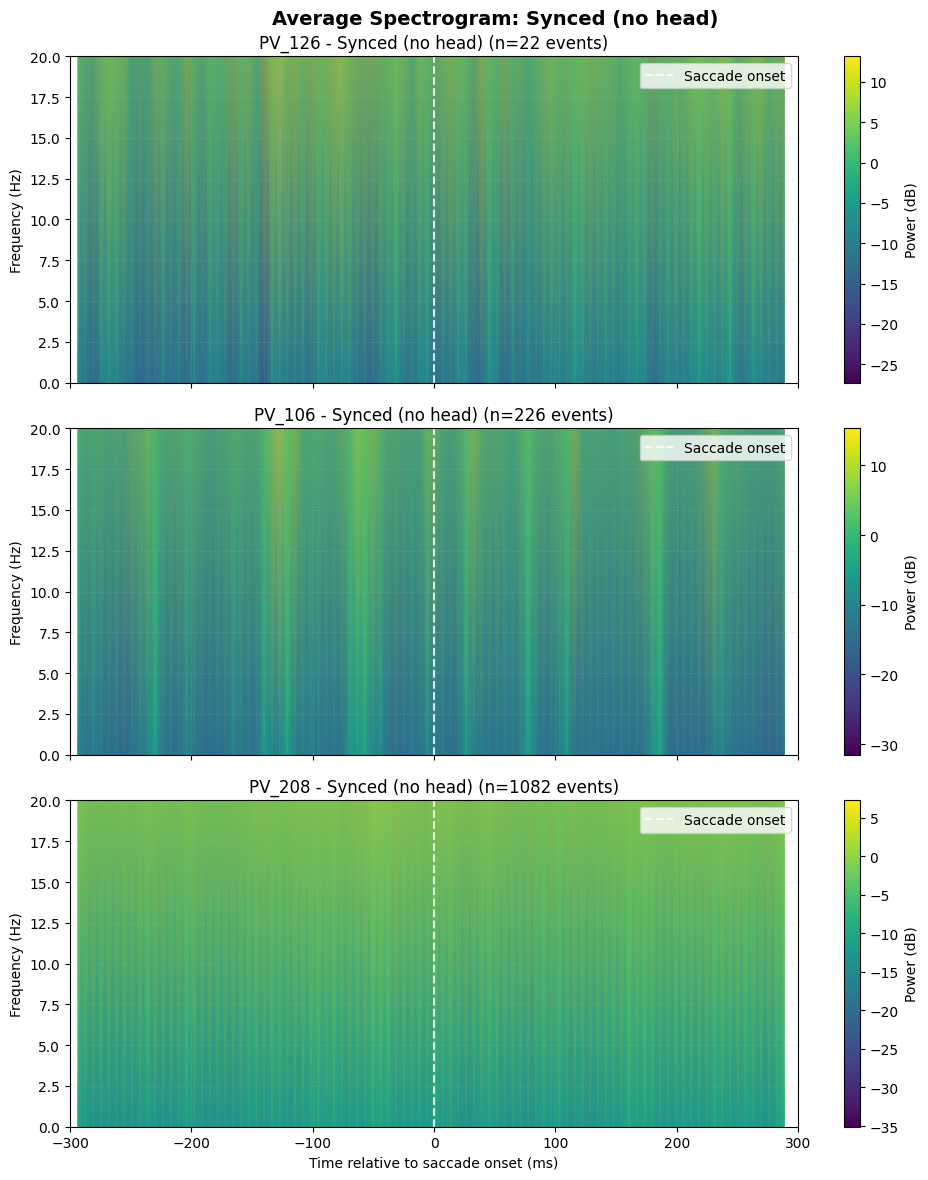


Spectrogram analysis complete!


In [23]:
# =============================================================================
# Secondary SPECTROGRAM ANALYSIS: Average spectrogram aligned to saccade onset, 
# additional call cell with different specs
# =============================================================================

from scipy import signal
import matplotlib.colors as mcolors

# =============================================================================
# PARAMETERIZATION SECTION - select subset of animals and conditions
# -----------------------------------------------------------------------------
# - To plot only certain animals, add their names to `animals_to_plot`, e.g. ['PV_126', 'PV_208']
# - To plot only certain conditions, add their names to `conditions_to_plot`, e.g. ['All Saccades', 'Leftward']
# - Leave as None or empty list [] to plot ALL available
# - `filtered_collections` is a list of (condition_name, df) tuples.
# - The available animal names and condition names should be printed below for reference.
# =============================================================================

# List all available conditions and animals in your current run:
available_conditions = [name for name, _ in filtered_collections]
available_animals    = sorted(set(a for df in [x[1] for x in filtered_collections] for a in df['animal'].unique()))

print("Available conditions:", available_conditions)
print("Available animals:   ", available_animals)

# ---- Set to subsets as needed: ----
animals_to_plot     = None       # e.g. ['PV_126', 'PV_106']
conditions_to_plot  = ['Synced (no head)']       # e.g. ['All Saccades']

# ---- Normalize settings: ----
if animals_to_plot is not None and not isinstance(animals_to_plot, (list, tuple, set)):
    animals_to_plot = [animals_to_plot]
if conditions_to_plot is not None and not isinstance(conditions_to_plot, (list, tuple, set)):
    conditions_to_plot = [conditions_to_plot]

# =============================================================================
# CONFIGURATION (unchanged)
# =============================================================================
spectrogram_window_ms = 600  # ±2 seconds = 4 seconds total
spectrogram_half_window_ms = spectrogram_window_ms / 2
# Sampling rate will be auto-detected from data, but you can override here if needed
spectrogram_fs = None  # If None, will be computed from first window: fs = n_samples / (window_ms / 1000)
nperseg = 256  # Window length for spectrogram (samples) - adjust for desired frequency resolution
noverlap = nperseg // 2  # 50% overlap
nfft = 512  # FFT length (can be larger than nperseg for zero-padding)
max_freq_display = 20  # Maximum frequency to display in plots (Hz) - adjust as needed



# =============================================================================
# Run the analysis with selection logic
# =============================================================================
print("Computing average spectrograms for each filtered collection (with selected animals and conditions)...")
print("Note: Sampling rate will be auto-detected from the data if not specified, and subset selection applies if set.")

spectrogram_results = {}

for name, df in filtered_collections:
    # Filter by condition
    if conditions_to_plot and name not in conditions_to_plot:
        continue

    # Subset animal list as needed:
    animals_arg = animals_to_plot if animals_to_plot is not None else animals

    print(f"\nProcessing: {name}")
    spectrogram_per_animal = extract_spectrogram_per_animal(
        df, block_dict, lfp_channels, 
        spectrogram_window_ms, spectrogram_half_window_ms,
        animals_arg, spectrogram_fs, nperseg, noverlap, nfft,
        noise_filter_std=lfp_noise_filter_std
    )
    
    if spectrogram_per_animal:
        # Only keep selected animals (in case extract returns more), to enforce a consistent view
        if animals_to_plot is not None:
            animal_spec_subset = {k: v for k, v in spectrogram_per_animal.items() if k in animals_to_plot}
        else:
            animal_spec_subset = spectrogram_per_animal
        spectrogram_results[name] = animal_spec_subset
        for animal, (freqs, times, spec, n_events, _) in animal_spec_subset.items():
            print(f"  {animal}: {n_events} events, freq range: {freqs[0]:.1f}-{freqs[-1]:.1f} Hz")

# Plot spectrograms
print("\n" + "="*60)
print("Plotting average spectrograms...")
print("="*60)

for name, spec_dict in spectrogram_results.items():
    if not spec_dict:
        continue

    n_animals = len(spec_dict)
    fig, axes = plt.subplots(n_animals, 1, figsize=(10, 4 * n_animals), sharex=True, sharey=True)
    
    if n_animals == 1:
        axes = [axes]
    
    for idx, (animal, (freqs, times, avg_spec, n_events, _)) in enumerate(spec_dict.items()):
        ax = axes[idx]
        
        # Plot spectrogram
        # Use log scale for power (dB)
        spec_db = 10 * np.log10(avg_spec + 1e-10)  # Add small value to avoid log(0)
        
        im = ax.pcolormesh(times * 1000, freqs, spec_db, shading='gouraud', cmap='viridis')
        ax.axvline(0, color='white', linestyle='--', linewidth=1.5, alpha=0.8, label='Saccade onset')
        ax.set_ylabel('Frequency (Hz)')
        ax.set_title(f'{animal} - {name} (n={n_events} events)')
        ax.set_xlim(-spectrogram_half_window_ms, spectrogram_half_window_ms)
        ax.set_ylim(0, min(max_freq_display, freqs[-1]))  # Show up to max_freq_display Hz
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Power (dB)')
        
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Time relative to saccade onset (ms)')
    fig.suptitle(f'Average Spectrogram: {name}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

print("\nSpectrogram analysis complete!")